# Modeling: recommendation experiments

## 1. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "pyproject.toml").is_file():
            return p
    return (here / "..").resolve()


ROOT = _project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
import pandas as pd
import scipy
from typing import Dict

from loaders import DataLoader

data_loader = DataLoader()


## 2. Load train, test, and embeddings

In [2]:
import numpy as np

processed = ROOT / "data" / "processed"


def _read_clicks_temporal(stem: str) -> pd.DataFrame:
    pq, csv_gz = processed / f"{stem}.parquet", processed / f"{stem}.csv.gz"
    if pq.is_file():
        return pd.read_parquet(pq)
    if csv_gz.is_file():
        return pd.read_csv(csv_gz, parse_dates=["click_timestamp"])
    raise FileNotFoundError(f"Missing {pq} or {csv_gz}; run EDA temporal split first.")


train_df = _read_clicks_temporal("clicks_train_temporal")
test_df = _read_clicks_temporal("clicks_test_temporal")
display(train_df.head())
print(train_df.shape)
print(f'Unique number of users in train: {train_df["user_id"].nunique()}')
display(test_df.head())
print(test_df.shape)
print(f'Unique number of users in test: {test_df["user_id"].nunique()}')

emb_npz = processed / "article_embeddings_temporal_union.npz"
if emb_npz.is_file():
    z = np.load(emb_npz)
    _ids = z["article_id"]
    _emb = z["embedding"]
    article_id_to_embedding = {int(_ids[i]): _emb[i].copy() for i in range(len(_ids))}
else:
    logging.warning(
        "Missing %s — falling back to full matrix (row i = article_id i). Run EDA temporal split to export npz.",
        emb_npz.name,
    )
    full = data_loader.load_article_embeddings_matrix()
    article_id_to_embedding = {i: full[i] for i in range(len(full))}

print(
    f"{len(article_id_to_embedding):,} article_id → embedding (subset for train∪test temporal split)"
)
_a0 = next(iter(article_id_to_embedding))
display(article_id_to_embedding[_a0][:8])

,user_id,session_id,session_start,session_size,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,137432,1507091833314122,2017-10-04 04:37:13,2,2017-10-04 04:37:50.976,4,4,2,1,5,2,157078,281,2017-10-03 20:03:46,0,269
1,137432,1507091833314122,2017-10-04 04:37:13,2,2017-10-04 04:38:20.976,4,4,2,1,5,2,161602,281,2017-10-03 16:10:27,0,248
2,151078,1507091871132126,2017-10-04 04:37:51,3,2017-10-04 04:38:02.993,4,1,17,10,28,2,207994,331,2017-10-03 20:54:01,0,177
3,151078,1507091871132126,2017-10-04 04:37:51,3,2017-10-04 04:39:54.483,4,1,17,10,28,2,206090,331,2017-10-03 23:03:43,0,244
4,151078,1507091871132126,2017-10-04 04:37:51,3,2017-10-04 04:40:24.483,4,1,17,10,28,2,156619,281,2017-10-03 11:44:02,0,275


(881392, 16)
Unique number of users in train: 64734


,user_id,session_id,session_start,session_size,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,article_id,category_id,created_at_ts,publisher_id,words_count
0,93863,1507865792177843,2017-10-13 03:36:32,2,2017-10-13 03:37:12.925,4,3,2,1,21,2,96210,209,2017-10-12 08:59:51,0,274
1,93863,1507865792177843,2017-10-13 03:36:32,2,2017-10-13 03:37:42.925,4,3,2,1,21,2,158094,281,2017-10-12 10:22:31,0,223
2,77136,1507865796257845,2017-10-13 03:36:36,2,2017-10-13 03:42:13.178,4,3,2,1,25,2,336245,437,2017-10-12 05:18:51,0,150
3,77136,1507865796257845,2017-10-13 03:36:36,2,2017-10-13 03:42:43.178,4,3,2,1,25,2,96210,209,2017-10-12 08:59:51,0,274
4,16921,1507865798301846,2017-10-13 03:36:38,2,2017-10-13 03:37:38.065,4,1,17,1,9,1,159197,281,2017-10-12 17:43:34,0,299


(771758, 16)
Unique number of users in test: 64734
28,131 article_id → embedding (subset for train∪test temporal split)


array([-0.7008142 , -0.9659266 , -0.1818693 , -0.42350376, -0.02466794,
        0.18706073, -0.67465675, -0.10877775], dtype=float32)

In [95]:
print("Average of clicks per user in the train set:")
print(f"{train_df.groupby('user_id').size().mean()}")

print("Average of clicks per user in the test set:")
print(f"{test_df.groupby('user_id').size().mean()}")


Average of clicks per user in the train set:
13.6155961318627
Average of clicks per user in the test set:
11.921988445021164


In [ ]:
train_df.reset_index(drop=True).groupby("user_id").size().describe()

count    64734.000000
mean        13.615596
std         14.515561
min          1.000000
25%          5.000000
50%          9.000000
75%         17.000000
max        552.000000
dtype: float64

In [ ]:
(train_df.reset_index(drop=True).groupby("user_id").size() == 1).sum()

np.int64(40)

In [3]:
DAYS_WINDOW = 7

#### Select random users for case illustration

In [4]:
import random
USER_COL = "user_id"
ITEM_COL = "article_id"

# random.seed(EVAL_SEED)
demo_user1 = int(random.choice(test_df[USER_COL].unique()))
demo_user2 = int(random.choice(test_df[USER_COL].unique()))
print(f"Demo demo_user1={demo_user1} (present in both train and test from EDA split)")

print("Train history (used to build the profile):")
print(f"Demo demo_user1={demo_user1} read {len(train_df.loc[train_df[USER_COL] == demo_user1])} in the train set and {len(test_df.loc[test_df[USER_COL] == demo_user1])} in the test set")
print(f"Demo demo_user2={demo_user2} (present in both train and test from EDA split)")
print(f"Demo demo_user2={demo_user2} read {len(train_df.loc[train_df[USER_COL] == demo_user2])} in the train set and {len(test_df.loc[test_df[USER_COL] == demo_user2])} in the test set")

demo_users = [demo_user1, demo_user2]

Demo demo_user1=138255 (present in both train and test from EDA split)
Train history (used to build the profile):
Demo demo_user1=138255 read 2 in the train set and 6 in the test set
Demo demo_user2=51228 (present in both train and test from EDA split)
Demo demo_user2=51228 read 34 in the train set and 36 in the test set


## 3. Modeling


### 3.1 Content-based



Content-based filtering approaches leverage description or attributes from items the user has interacted to recommend similar items. It depends only on the user previous choices, making this method robust to avoid the cold-start problem. For textual items, like articles, news and books, it is simple to use the raw text to build item profiles and user profiles.

Here, the articles texts features and metadata  inputs were combined by using a sequence of Fully Connected (FC) layers in a 1D CNN neural network model to produce Article Content Embeddings.

1. To model the user profile, we take all the item profiles the user has interacted and average them. The average is weighted by the interaction strength, in other words, the articles the user has interacted the most (clicked) will have a higher strength in the final user profile.

In [5]:
from typing import Dict, List, Set, Any, Optional
import time

class CBRecommender:
    """
    Content-Based recommender for experimentation.
    Allows testing and combining profiles: Mean, Recency, and Category Weighted.
    """
    def __init__(self, data_loader, user_col: str = "user_id", item_col: str = "article_id", timestamp_col: str = "click_timestamp"):
        self.data_loader = data_loader
        self.user_col = user_col
        self.item_col = item_col
        self.timestamp_col = timestamp_col

        # Global article catalogue data
        self.candidate_ids: np.ndarray = np.array([])
        self.candidate_embeddings: np.ndarray = np.array([[]])
        self.candidate_norms: np.ndarray = np.array([])

        # Metadata dictionaries (O(1) access)
        self.article_to_idx: Dict[int, int] = {}
        self.category_by_article: Dict[int, int] = {}
        self.created_ts_by_article: Dict[int, int] = {}

        # User profiles calculated
        self.user_profiles: Dict[int, np.ndarray] = {}
        self.user_seen: Dict[int, Set[int]] = {}

        # Popularity scores
        self.popularity_scores: Dict[int, float] = {}

    def fit(self, train_df: pd.DataFrame, strategy: str = "mean", half_life_days: float = 7.0, top_n_categories: Optional[int] = None):
        """
        Trains the model according to the chosen strategy.
        Available strategies: 'mean', 'recency', 'category'
        """
        print("1/3. Loading and indexing article catalogue...")
        metadata = self.data_loader.load_articles_metadata()
        self.candidate_ids = metadata["article_id"].dropna().astype(int).unique()
        self.article_to_idx = {int(aid): i for i, aid in enumerate(self.candidate_ids)} # Create a dictionary mapping article IDs to their indices

        # Retrieving all necessary embeddings at once
        emb = self.data_loader.get_embeddings_by_ids(self.candidate_ids.tolist())
        self.candidate_embeddings = np.asarray(emb, dtype=np.float32)

        # Pre-calculating norms for cosine
        self.candidate_norms = np.linalg.norm(self.candidate_embeddings, axis=1)
        self.candidate_norms = np.where(self.candidate_norms == 0.0, 1e-12, self.candidate_norms) # Replace 0 values with a small epsilon to avoid division by zero

        # Loading metadata via data_loader
        self.category_by_article = self.data_loader.get_category_map(self.candidate_ids) # Link each article ID to its category
        self.created_ts_by_article = self.data_loader.get_article_created_ts_map(self.candidate_ids) # Link each article ID to its creation date

        print("2/3. Mapping user histories...")
        # Native storage of seen items for masking at recommendation time
        seen_grouped = train_df.groupby(self.user_col)[self.item_col].apply(set).to_dict() # Group the items by user
        self.user_seen = {int(k): {int(i) for i in v} for k, v in seen_grouped.items()} # Create a dictionary mapping each user to the set of items they have seen

        print(f"3/3. Calculating user profiles according to strategy: '{strategy}'...")
        all_train_aids = train_df[self.item_col].dropna().astype(int).unique().tolist()
        all_train_emb = self.data_loader.get_embeddings_by_ids(all_train_aids)
        aid_to_emb = {aid: all_train_emb[i] for i, aid in enumerate(all_train_aids)}

        # Precalculate popularity scores
        print("4/4. Loading popularity scores...")
        popular_df = self.data_loader.get_recent_popular_articles()

        if not popular_df.empty:
            # Normalize between 0 and 1
            pop_min = popular_df["popularity_score"].min()
            pop_max = popular_df["popularity_score"].max()
            pop_range = pop_max - pop_min if pop_max != pop_min else 1.0

            self.popularity_scores = {
                int(row["article_id"]): (row["popularity_score"] - pop_min) / pop_range
                for _, row in popular_df.iterrows()
            }
        else:
            self.popularity_scores = {}

        # Extracting interactions sorted by time if recency is required
        if strategy == "recency":
            train_df = train_df.sort_values(by=[self.user_col, self.timestamp_col])

        user_groups = train_df.groupby(self.user_col)

        for uid, group in user_groups:
            aids = group[self.item_col].dropna().astype(int).tolist()
            user_emb = np.array([aid_to_emb[aid] for aid in aids if aid in aid_to_emb],
                        dtype=np.float32)

            if user_emb.size == 0:
                continue

            if strategy == "mean":
                self.user_profiles[int(uid)] = user_emb.mean(axis=0)

            elif strategy == "recency":
                timestamps = group[self.timestamp_col].values  # shape (n_clicks,)
                max_ts = timestamps.max()

                # Calcul of the time delta in days since the most recent click
                deltas_days = (max_ts - timestamps) / np.timedelta64(1, 'D')

                # Exponential decay: half_life_days controls the speed
                weights = np.exp(-deltas_days / half_life_days)
                weights /= weights.sum()

                self.user_profiles[int(uid)] = np.dot(weights, user_emb)

            elif strategy == "category" and top_n_categories is not None:
                # Category Profile: Overweight embeddings of articles belonging to top categories
                cats = [self.category_by_article.get(aid) for aid in aids if self.category_by_article.get(aid) is not None]
                if cats:
                    counts = pd.Series(cats).value_counts().head(top_n_categories)
                    top_cats = set(counts.index)

                    # We apply a boost to the articles of the history that have the right category
                    weights = np.array([2.0 if self.category_by_article.get(aid) in top_cats
                                else 1.0 for aid in aids], dtype=np.float32)
                    weights /= weights.sum()
                    self.user_profiles[int(uid)] = np.dot(weights, user_emb)
                else:
                    self.user_profiles[int(uid)] = user_emb.mean(axis=0)
            else:
                # Fallback by default
                self.user_profiles[int(uid)] = user_emb.mean(axis=0)
        print("Model ready for predictions.")
        return self

    def recommend_batch(self, user_ids: List[int], n: int = 5, train_df: Optional[pd.DataFrame] = None, days_window: Optional[int] = None, test_df: Optional[pd.DataFrame] = None, beta: float = 0.0) -> Dict[int, List[int]]:
        """Calculate Top-N in a vectorized way for a batch of users, with an optional temporal window."""
        recs: Dict[int, List[int]] = {}

        # Filter the candidate items that are in a defined temporal window (For recent articles only)
        temporal_mask_indexes = None
        if days_window is not None and train_df is not None:
            ref = train_df[self.timestamp_col].max()
            limit_date = ref - pd.Timedelta(days=days_window)

            # Valid recent articles
            recent_articles = train_df[train_df[self.timestamp_col] >= limit_date][self.item_col].dropna().astype(int).unique()
            recent_articles_set = set(recent_articles)

            if test_df is not None:
                recent_from_test = test_df[test_df[self.timestamp_col] >= limit_date][self.item_col] \
                    .dropna().astype(int).unique()
                recent_articles_set |= set(recent_from_test)

            # Lookup all indexes of our catalog that are NOT recent
            temporal_mask_indexes =[idx for aid, idx in self.article_to_idx.items() if aid not in recent_articles_set]

        for uid in user_ids:
            profile = self.user_profiles.get(uid)
            if profile is None:
                continue

            u_norm = np.linalg.norm(profile)
            if u_norm == 0:
                continue

            # Semantic CB score (Pure matrix product (364 047 cosine calculations at once) == scalar product between the article embedding matrix and the user profile vector)
            cb_scores = (self.candidate_embeddings @ profile) / (self.candidate_norms * u_norm)

            # Hybrid score (CB + popularity)
            if beta > 0.0 and self.popularity_scores:
                pop_scores = np.array([
                    self.popularity_scores.get(int(aid), 0.0)
                    for aid in self.candidate_ids
                ], dtype=np.float32)
                scores = (1 - beta) * cb_scores + beta * pop_scores
            else:
                scores = cb_scores

            # Already seen items mask (push them to -infinity)
            seen_set = self.user_seen.get(uid, set())
            seen_indices = [self.article_to_idx[aid] for aid in seen_set if aid in self.article_to_idx]
            if seen_indices:
                scores[seen_indices] = -np.inf

            # Temporal mask
            if temporal_mask_indexes is not None:
                scores[temporal_mask_indexes] = -np.inf

            # Retrieving the N best elements without sorting the whole array (np.argpartition)
            if len(scores) > n:
                top_indices = np.argpartition(scores, -n)[-n:]
                top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
            else:
                top_indices = np.argsort(scores)[::-1]

            recs[uid] = self.candidate_ids[top_indices].tolist()

        return recs

    def evaluate(
            self,
            test_df: pd.DataFrame,
            similarity_threshold: float = 0.7,
            topk: int = 5,
            train_df: Optional[pd.DataFrame] = None,
            days_window: Optional[int] = None,
            batch_size: int = 500,
            beta: float = 0.0) -> pd.DataFrame:
        """
            Calculate Hit Rate (Top-N Accuracy) at scale, forward-passing temporal argument and a semantic soft hit.
        """

        test_grouped = test_df.groupby(self.user_col)[self.item_col].apply(set).to_dict()

        # Filter on users that have a semantic profile in the CB
        valid_users = [uid for uid in test_grouped.keys() if self.user_profiles.get(uid) is not None]

        if not valid_users:
            return pd.DataFrame()

        recall_ks = [5, 10, 20]
        max_k = max(topk, max(recall_ks))

        # Loading temporal mask once
        temporal_mask = np.ones(len(self.candidate_ids), dtype=bool)
        if days_window is not None and train_df is not None:
            max_ts = train_df[self.timestamp_col].max()
            limit_date = max_ts - pd.Timedelta(days=days_window)

            recent_ids = set(train_df[train_df[self.timestamp_col] >= limit_date][self.item_col]
                            .dropna().astype(int).unique())
            recent_ids |= set(test_df[self.item_col].dropna().astype(int).unique())

            temporal_mask = np.array([
                int(aid) in recent_ids for aid in self.candidate_ids
            ], dtype=bool)

        # Pre-calculating norms for cosine once
        norms_safe = np.where(self.candidate_norms == 0, 1e-12, self.candidate_norms)
        emb_norm = (self.candidate_embeddings / norms_safe[:, np.newaxis]).astype(np.float32)
        emb_norm[~temporal_mask] = 0.0  # ces articles auront score -inf

        classic_hits = []
        soft_hits = []
        recall_scores = {k: [] for k in recall_ks}

        # Pre-calculating the popularity vector once (shape: n_candidates)
        if beta > 0.0 and self.popularity_scores:
            pop_vector = np.array([
                self.popularity_scores.get(int(aid), 0.0)
                for aid in self.candidate_ids
            ], dtype=np.float32)
            pop_vector[~temporal_mask] = 0.0  # temporal mask consistent
        else:
            pop_vector = None

        for batch_start in range(0, len(valid_users), batch_size):
            batch_users = valid_users[batch_start : batch_start + batch_size]

            # Profiles matrix (batch_size × dim)
            profiles = np.array([self.user_profiles[uid] for uid in batch_users], dtype=np.float32)
            user_norms = np.linalg.norm(profiles, axis=1, keepdims=True)
            user_norms = np.where(user_norms == 0, 1e-12, user_norms)
            profiles_norm = profiles / user_norms

            # Scores : One matrix product for the whole batch (batch_size × n_candidates)
            batch_scores = profiles_norm @ emb_norm.T
            batch_scores[:, ~temporal_mask] = -np.inf

            # Add popularity: broadcasting on all lines of the batch
            if pop_vector is not None:
                batch_scores = (1 - beta) * batch_scores + beta * pop_vector[np.newaxis, :]

            for i, uid in enumerate(batch_users):
                scores = batch_scores[i].copy()

                # Hide already seen items
                seen_set = self.user_seen.get(uid, set())
                seen_indices = [self.article_to_idx[aid] for aid in seen_set if aid in self.article_to_idx]
                if seen_indices:
                    scores[seen_indices] = -np.inf

                # Top max K
                top_indices = np.argpartition(scores, -max_k)[-max_k:]
                top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
                all_predicted = self.candidate_ids[top_indices].tolist()

                true_items = test_grouped[uid]
                n_relevant = len(true_items)

                # Hit@5
                predicted_topk = all_predicted[:topk]
                has_hit = any(item in true_items for item in predicted_topk)
                classic_hits.append(1.0 if has_hit else 0.0)

                # Soft hit@5
                if has_hit:
                    soft_hits.append(1.0)
                else:
                    top_scores = [scores[top_indices[j]] for j in range(topk)]
                    max_sim = max(top_scores) if top_scores else 0.0
                    soft_hits.append(0.5 if max_sim >= similarity_threshold else 0.0)

                # Recall@K
                for k in recall_ks:
                    predicted_k = all_predicted[:k]
                    n_hits_k = sum(1 for item in predicted_k if item in true_items)
                    recall_scores[k].append(min(n_hits_k / n_relevant, 1.0) if n_relevant > 0 else 0.0)

            print(f"  {min(batch_start + batch_size, len(valid_users))}/{len(valid_users)} users...", end="\r")

        results = {
            "acc@5": float(np.mean(classic_hits).round(4)),
            "soft@5": float(np.mean(soft_hits).round(4)),
        }
        for k in recall_ks:
            results[f"recall@{k}"] = float(np.mean(recall_scores[k]).round(4))

        return pd.DataFrame([results])


In [113]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_user_recommendations_2d(user_id: int, recommender, df_train: pd.DataFrame, df_test: pd.DataFrame, recommendations: list, data_loader):
    """
    Plots a 2D PCA graph of the user profile, history, and recommendations.
    """
    # 1. IDs of articles
    train_aids = df_train.loc[df_train[recommender.user_col] == user_id, recommender.item_col].dropna().astype(int).tolist()
    test_aids = df_test.loc[df_test[recommender.user_col] == user_id, recommender.item_col].dropna().astype(int).tolist()
    rec_aids = list(recommendations)


    if not train_aids:
        print(f"⚠️ No history in the Train for user {user_id}. Impossible to plot the graph.")
        return

    # 2. User profile
    user_profile = recommender.user_profiles.get(user_id)
    if user_profile is None:
        print(f"⚠️ No profile found for user {user_id} (absent from model).")
        return
    user_profile = user_profile.reshape(1, -1)

    # 3. Secure retrieval of embeddings (Train, Test, Recs)
    train_embs = data_loader.get_embeddings_by_ids(train_aids)
    test_embs = data_loader.get_embeddings_by_ids(test_aids) if test_aids else np.array([])
    rec_embs = data_loader.get_embeddings_by_ids(rec_aids) if rec_aids else np.array([])

    # 4. Stacking matrices for PCA
    matrices_to_stack = [train_embs]
    if test_embs.size > 0:
        matrices_to_stack.append(test_embs)
    if rec_embs.size > 0:
        matrices_to_stack.append(rec_embs)
    matrices_to_stack.append(user_profile)

    all_embs = np.vstack(matrices_to_stack)

    # 5. PCA projection in 2D
    pca = PCA(n_components=2, random_state=42)
    all_embs_2d = pca.fit_transform(all_embs)

    # 6. Splitting coordinates
    idx = 0
    train_2d = all_embs_2d[idx : idx + len(train_aids)]; idx += len(train_aids)

    test_2d = None
    if test_embs.size > 0:
        test_2d = all_embs_2d[idx : idx + len(test_aids)]; idx += len(test_aids)

    # Extraction and projection of recommendations separately
    rec_2d = None
    if recommendations is not None and len(recommendations) > 0:
        # 1. Ensure clean and unique IDs
        clean_rec_aids = [int(aid) for aid in recommendations if aid is not None]

        # 2. Retrieve their embeddings directly via the data_loader
        try:
            rec_embs = data_loader.get_embeddings_by_ids(clean_rec_aids)
            if rec_embs.size > 0:
                # 3. Apply the same PCA transformation as for the rest
                rec_2d = pca.transform(rec_embs)
        except Exception as e:
            print(f"Error projecting recommendations: {e}")
            rec_2d = None

    profile_2d = all_embs_2d[idx]

    # 7. Construction and display of the graph
    plt.figure(figsize=(11, 7))

    # Train history
    plt.scatter(train_2d[:, 0], train_2d[:, 1], color='royalblue', alpha=0.7, edgecolors='k', s=80, label=f'Historique Train ({len(train_aids)} items)')

    # Future real (Test) - optional if the user has nothing in the test
    if test_2d is not None:
        plt.scatter(test_2d[:, 0], test_2d[:, 1], color='limegreen', alpha=0.9, edgecolors='k', s=130, marker='X', label=f'Future Real Test ({len(test_aids)} items)')

    # Display model recommendations
    if rec_2d is not None and len(rec_2d) > 0:
        plt.scatter(
            rec_2d[:, 0],
            rec_2d[:, 1],
            color='crimson',
            alpha=0.9,
            edgecolors='k',
            s=120,          # Slightly larger to see them better
            marker='^',
            label=f'Top-{len(rec_2d)} Recommendations' # Use the true projected size
        )
    # The profile (center of gravity calculated)
    plt.scatter(profile_2d[0], profile_2d[1], color='gold', edgecolor='black', s=350, marker='*', label='User Profile (Center)', zorder=5)

    plt.title(f"Vector analysis for user {user_id}", fontsize=13, fontweight='bold')
    plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} var)")
    plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} var)")
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

Testing strategy: Mean for user 13355
1/3. Loading and indexing article catalogue...


/Users/ikusawalaetitia/Documents/oc-projects/python/aiengineer/P10-content_recommandation_app/loaders.py:71: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  self._articles_embeddings = pickle.load(f)


2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.
Number of accurate recommendations: 0


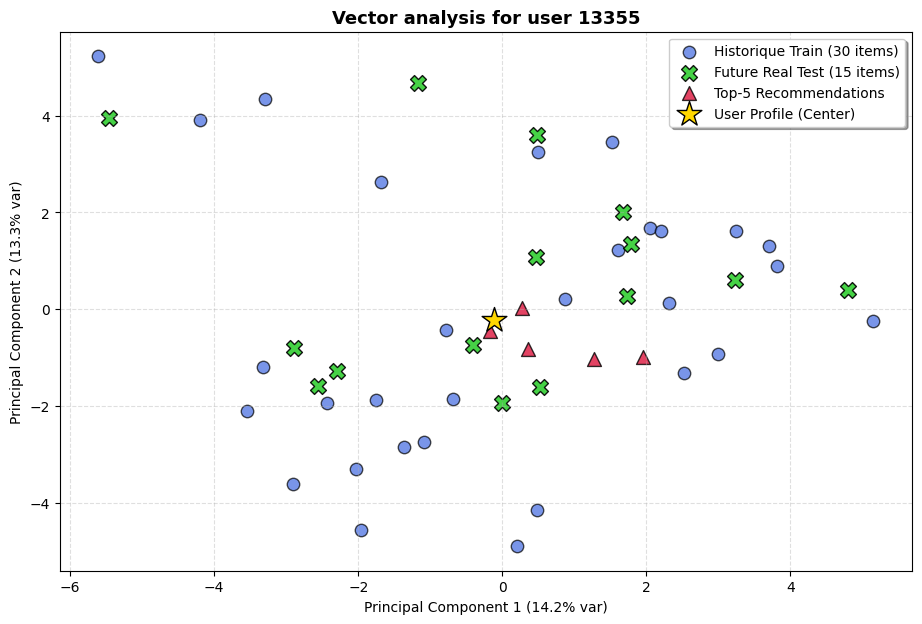

Testing strategy: Recency for user 13355
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'recency'...
Model ready for predictions.


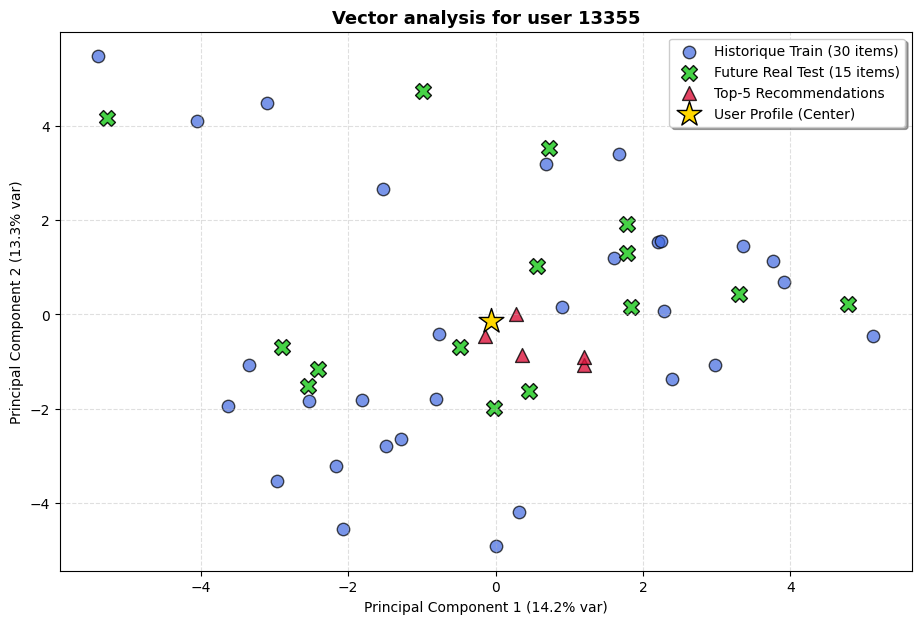

Testing strategy: Category for user 13355
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
Model ready for predictions.


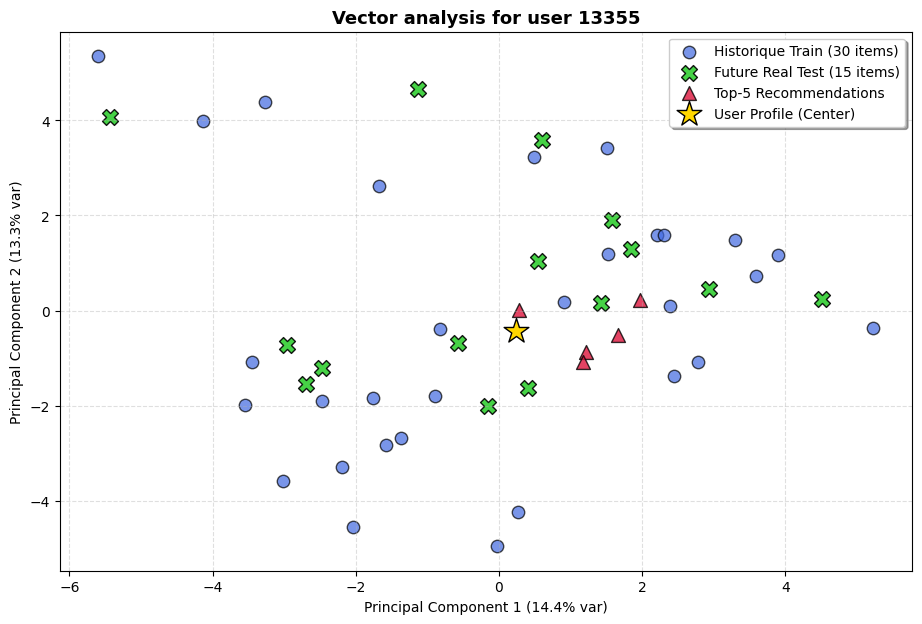

Testing strategy: Mean for user 55206
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.
Number of accurate recommendations: 0


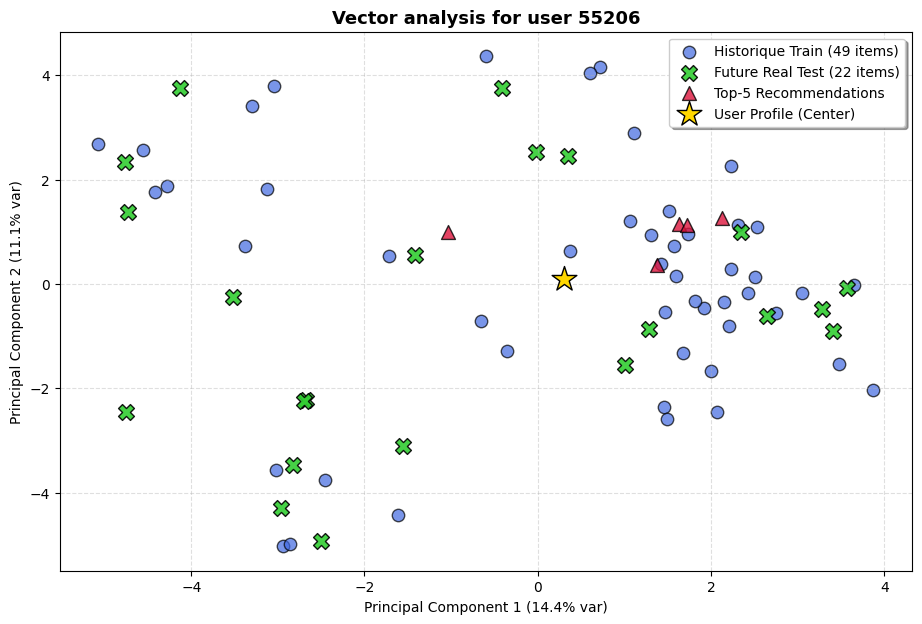

Testing strategy: Recency for user 55206
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'recency'...
Model ready for predictions.


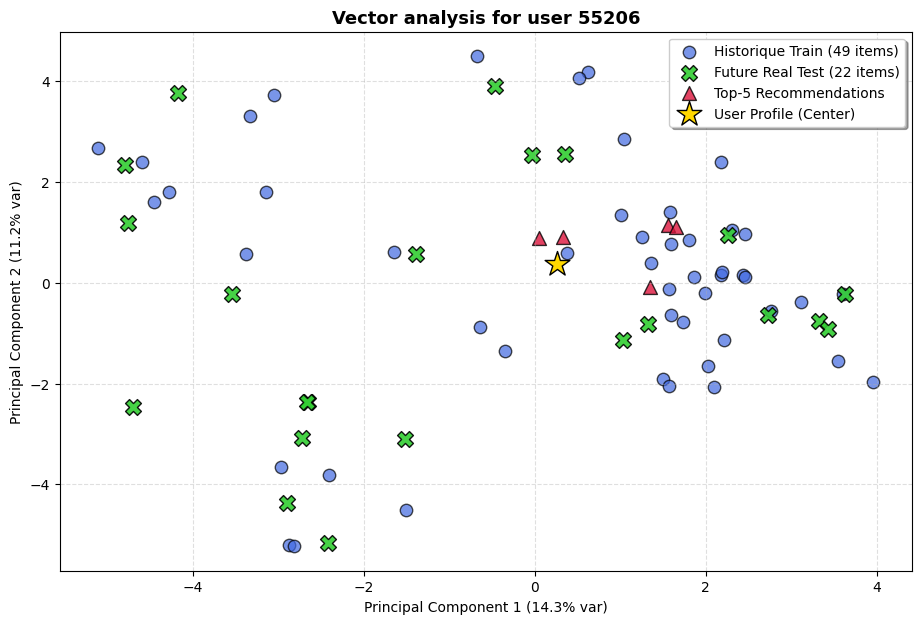

Testing strategy: Category for user 55206
1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
Model ready for predictions.


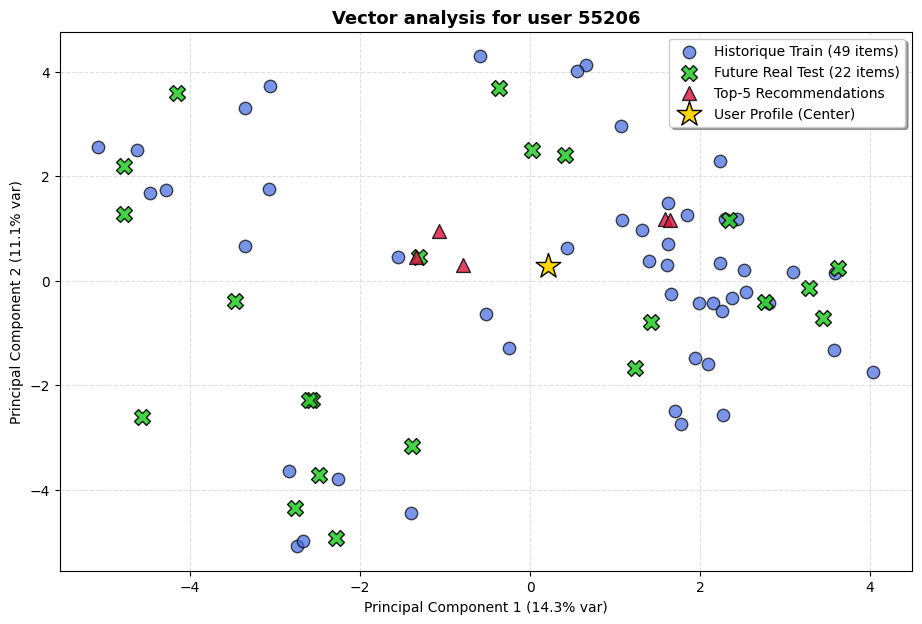

In [ ]:
CB_model = CBRecommender(data_loader=data_loader)
for demo_user in demo_users:
    # --- TEST 1 : MEAN STRATEGY ---
    print(f"Testing strategy: Mean for user {demo_user}")
    CB_model.fit(train_df, strategy="mean")
    recs_mean = CB_model.recommend_batch([demo_user], n=5, train_df=train_df, days_window=DAYS_WINDOW).get(demo_user, [])
    print(f"Number of accurate recommendations: {sum(1 for item in recs_mean if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())}")

    # Call the graph function
    plot_user_recommendations_2d(demo_user, CB_model, train_df, test_df, recs_mean, data_loader)


    # --- TEST 2 : RECENCY STRATEGY ---
    print(f"Testing strategy: Recency for user {demo_user}")
    CB_model.fit(train_df, strategy="recency")
    recs_recency = CB_model.recommend_batch([demo_user], n=5, train_df=train_df, days_window=DAYS_WINDOW).get(demo_user, [])

    # Call the graph function (the star will move!)
    plot_user_recommendations_2d(demo_user, CB_model, train_df, test_df, recs_recency, data_loader)

    # --- TEST 3 : CATEGORY STRATEGY ---
    print(f"Testing strategy: Category for user {demo_user}")
    CB_model.fit(train_df, strategy="category", top_n_categories=2)
    recs_category = CB_model.recommend_batch([demo_user], n=5, train_df=train_df, days_window=DAYS_WINDOW).get(demo_user, [])

    # Call the graph function (the star will move!)
    plot_user_recommendations_2d(demo_user, CB_model, train_df, test_df, recs_category, data_loader)


#### Baseline ( Average profile)

In [76]:
base = CBRecommender(data_loader=data_loader)
base.fit(train_df, strategy="mean")

n_catalogue = len(base.candidate_ids)
n_embeddings = len(base.candidate_embeddings)
print(f"Catalog: {n_catalogue} articles, Embeddings: {n_embeddings}")

# Direct evaluation
results_mean = base.evaluate(test_df, topk=5, train_df=train_df, days_window=DAYS_WINDOW, batch_size=1000)

# Add strategy to the DataFrame
results_mean['strategy'] = 'Mean'
results_df = results_mean
display(results_df)

1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'mean'...
Model ready for predictions.
Catalog: 364047 articles, Embeddings: 364047


,acc@5,soft@5,recall@5,recall@10,recall@20,strategy
0,0.0247,0.5093,0.0022,0.0044,0.0084,Mean


#### Temporal recency

In [77]:
import copy
cb_rec  = copy.copy(base) # Avoid reloading catalog - RAM optimization
cb_rec.fit(train_df, strategy="recency")

results_rec = cb_rec.evaluate(test_df, topk=5, train_df=train_df, days_window=DAYS_WINDOW, batch_size=1000)

# Add results to the DataFrame
results_rec['strategy'] = 'Recency'
results_df = pd.concat([results_df, results_rec])
display(results_df)


1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'recency'...
Model ready for predictions.


,acc@5,soft@5,recall@5,recall@10,recall@20,strategy
0,0.0247,0.5093,0.0022,0.0044,0.0084,Mean
0,0.0258,0.5096,0.0023,0.0045,0.0084,Recency


#### Top N categories

In [78]:
cb_cat = copy.copy(base)
cb_cat.fit(train_df, strategy="category", top_n_categories=3)

results_cat = cb_cat.evaluate(test_df, topk=5, batch_size=1000, train_df=train_df, days_window=DAYS_WINDOW)

# Add results to the DataFrame
results_cat['strategy'] = 'Category'
results_df = pd.concat([results_df, results_cat])
display(results_df)


1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
Model ready for predictions.


,acc@5,soft@5,recall@5,recall@10,recall@20,strategy
0,0.0247,0.5093,0.0022,0.0044,0.0084,Mean
0,0.0258,0.5096,0.0023,0.0045,0.0084,Recency
0,0.0259,0.5104,0.0023,0.0046,0.0088,Category


### 3.2 Collaborative filtering (implicit)

CF uses a sparse **user × item** matrix (SciPy sparse) from `train_df` and models from the [implicit](https://github.com/benfred/implicit) library (implicit feedback = clicks).

| Strategy | Class | Idea |
|----------|-------|------|
| **Item–item** | `ItemItemCosineCollaborativeFilteringRecommender` | Memory-based: articles co-read by similar users |
| **ALS** | `ALSCollaborativeFilteringRecommender` | Matrix factorization (Alternating Least Squares) |
| **BPR** | `BPRCollaborativeFilteringRecommender` | Pairwise ranking (clicked > not clicked) |
| **LMF** | `LMFCollaborativeFilteringRecommender` | Logistic matrix factorization |


We use the number of clicks as a Confident Signal for ALS, LMF and Item-Item. For BPR, we'll make a binary version of this information.

Same evaluation protocol as content-based: `Recommender.evaluate()` on `df_test` with Top-N Accuracy@K.


In [64]:
import implicit
from scipy.sparse import csr_matrix

print("Preparation of sparse matrices for 'implicit'...")

# 1. Create integer encodings (continuous indices) for users and articles
# This is mandatory for SciPy matrices to work without holes
user_categories = pd.Categorical(train_df[USER_COL])
item_categories = pd.Categorical(train_df[ITEM_COL])

train_df["user_idx"] = user_categories.codes
train_df["item_idx"] = item_categories.codes

# Mapping for later correspondence
user_to_idx = dict(zip(user_categories.categories, range(len(user_categories.categories))))
idx_to_user = {v: k for k, v in user_to_idx.items()}

item_to_idx = dict(zip(item_categories.categories, range(len(item_categories.categories))))
idx_to_item = {v: k for k, v in item_to_idx.items()}

# 2. Calculate weights (number of clicks per user/item pair)
grouped_train = train_df.groupby(["user_idx", "item_idx"]).size().reset_index(name="clicks")

# 3. Build the User x Items matrix (CSR format)
# implicit requires float32 for training
user_item_matrix = csr_matrix(
    (grouped_train["clicks"].astype(np.float32),
    (grouped_train["user_idx"], grouped_train["item_idx"])),
    shape=(len(user_categories.categories), len(item_categories.categories))
)

print(f"Matrix created : {user_item_matrix.shape[0]} users and {user_item_matrix.shape[1]} articles.")
print(f"Non-zero cells : {user_item_matrix.nnz:,}")
print(f"Sparsity       : {1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4%}")
print(f"Clicks total   : {int(user_item_matrix.sum()):,}")
print(f"Avg clicks/user: {user_item_matrix.sum(axis=1).mean():.1f}")
print(f"Max clicks on one article by one user: {int(user_item_matrix.max()):,}")

Preparation of sparse matrices for 'implicit'...
Matrix created : 64734 users and 16478 articles.
Non-zero cells : 881,392
Sparsity       : 99.9174%
Clicks total   : 881,392
Avg clicks/user: 13.6
Max clicks on one article by one user: 1


In [74]:
from typing import Optional, Tuple, List
import numpy as np
import pandas as pd

def evaluate_implicit_model(
    model,
    user_item_matrix,
    df_test: pd.DataFrame,
    user_to_idx: dict,
    item_to_idx: dict,
    idx_to_item: dict,
    cb_model,
    topk: int = 5,
    similarity_threshold: float = 0.7,
    train_df: Optional[pd.DataFrame] = None,
    days_window: Optional[int] = None,
    timestamp_col: Optional[str] = None,
    item_col: Optional[str] = None
) -> pd.DataFrame:
    """Calculate the Hit Rate (Top-N Accuracy) and Semantic Soft Hit for an implicit library model with an optional temporal window."""

    recall_ks = [5, 10, 20]
    max_k = max(topk, max(recall_ks))

    # Temporal window
    allowed_articles_set = None
    if days_window is not None and train_df is not None:
        max_timestamp = train_df[timestamp_col].max()
        limit_date = max_timestamp - pd.Timedelta(days=days_window)

        recent_train = set(
            train_df[train_df[timestamp_col] >= limit_date][item_col]
            .dropna().astype(int).unique()
        )

        # Add articles in the test set
        recent_test = set(df_test[item_col].dropna().astype(int).unique())
        allowed_articles_set = recent_train | recent_test

    test_grouped = df_test.groupby(cb_model.user_col)[cb_model.item_col].apply(set).to_dict()

    valid_users = [
    uid for uid in test_grouped.keys()
    if uid in user_to_idx and uid in cb_model.user_profiles
    ]
    user_idxs = [user_to_idx[uid] for uid in valid_users]

    if not user_idxs:
        return pd.DataFrame()

    # Asking for max_k candidates (+ margin if temporal filtering is active)
    query_limit = max_k * 3 if allowed_articles_set is not None else max_k

    # Native batch recommendation via implicit
    ids, _ = model.recommend(
        userid=user_idxs,
        user_items=user_item_matrix[user_idxs], # Only valid users
        N=query_limit,
        filter_already_liked_items=True
    )

    hits = []
    soft_hits = []
    recall_scores = {k: [] for k in recall_ks}

    for i, uid in enumerate(valid_users): # We loop on valid_users
        true_items = test_grouped[uid]
        n_relevant = len(true_items)


        # Convert matrix indices to real IDs
        predicted_items = [idx_to_item[item_idx] for item_idx in ids[i] if item_idx != -1 and item_idx in idx_to_item]

        # temporal filtering
        if allowed_articles_set is not None:
            predicted_items = [aid for aid in predicted_items if aid in allowed_articles_set]

        # --- Recall@K ---
        for k in recall_ks:
            predicted_k = predicted_items[:k]
            n_hits_k = sum(1 for item in predicted_k if item in true_items)
            recall_scores[k].append(
                min(n_hits_k / n_relevant, 1.0) if n_relevant > 0 else 0.0
            )

        # --- Hit@topk ---
        predicted_topk = predicted_items[:topk]

        if not predicted_topk:
            hits.append(0.0)
            soft_hits.append(0.0)
            continue

        has_hit = any(item in true_items for item in predicted_topk)
        hits.append(1.0 if has_hit else 0.0)

        # --- Soft hit ---
        if has_hit:
            soft_hits.append(1.0)
        else:
            user_profile = cb_model.user_profiles[uid]
            u_norm = np.linalg.norm(user_profile)

            if u_norm == 0:
                soft_hits.append(0.0)
                continue

            cosine_sims = []
            for item in predicted_topk:
                item_idx = cb_model.article_to_idx.get(item)
                if item_idx is None:
                    continue
                item_emb = cb_model.candidate_embeddings[item_idx]
                item_norm = cb_model.candidate_norms[item_idx]
                cosine_sims.append((item_emb @ user_profile) / (item_norm * u_norm))

            soft_hits.append(
                0.5 if cosine_sims and max(cosine_sims) >= similarity_threshold else 0.0
            )

    results = {
        "acc@5": float(np.mean(hits).round(4)),
        "soft@5": float(np.mean(soft_hits).round(4)),
    }
    for k in recall_ks:
        results[f"recall@{k}"] = float(np.mean(recall_scores[k]).round(4))

    return pd.DataFrame([results])


In [79]:
print("Training the Item-Item model...")
t0 = time.time()
model_item_item = implicit.nearest_neighbours.CosineRecommender(K=20)
model_item_item.fit(user_item_matrix)

results_cf = evaluate_implicit_model(model_item_item, user_item_matrix, test_df, user_to_idx, item_to_idx, idx_to_item, CB_model, topk=5, train_df=train_df, days_window=DAYS_WINDOW, timestamp_col="click_timestamp", item_col=ITEM_COL)

print(f"Time taken: {time.time() - t0:.2f} seconds")
results_cf['strategy'] = 'item-item'



print("Training the ALS model...")
t0 = time.time()
# Apply the recommended scaling alpha for implicit data (ex: Hu & Koren)
alpha_val = 40
scaled_matrix = (user_item_matrix * alpha_val).astype('float32')

model_als = implicit.als.AlternatingLeastSquares(factors=64, regularization=0.1, iterations=15, random_state=42)
model_als.fit(scaled_matrix)

results_als = evaluate_implicit_model(model_als, scaled_matrix, test_df, user_to_idx, item_to_idx, idx_to_item, CB_model, topk=5, train_df=train_df, days_window=DAYS_WINDOW, timestamp_col="click_timestamp", item_col=ITEM_COL)

print(f"Time taken: {time.time() - t0:.2f} seconds")
# Save results
results_als['strategy'] = 'als'
results_cf = pd.concat([results_cf, results_als])

print("Training the BPR model...")
t0 = time.time()
# The BPR uses only a binary matrix (0 or 1)
bpr_matrix = user_item_matrix.copy()
bpr_matrix.data = np.ones_like(bpr_matrix.data)

model_bpr = implicit.bpr.BayesianPersonalizedRanking(factors=64, regularization=0.01, iterations=30, random_state=42)
model_bpr.fit(bpr_matrix)

results_bpr = evaluate_implicit_model(model_bpr, bpr_matrix, test_df, user_to_idx, item_to_idx, idx_to_item, CB_model, topk=5, train_df=train_df, days_window=DAYS_WINDOW, timestamp_col="click_timestamp", item_col=ITEM_COL)

print(f"Time taken: {time.time() - t0:.2f} seconds")
results_bpr['strategy'] = 'bpr'
results_cf = pd.concat([results_cf, results_bpr])

print("Training the LMF model...")
t0 = time.time()
model_lmf = implicit.lmf.LogisticMatrixFactorization(factors=64, regularization=0.6, iterations=30, random_state=42)
model_lmf.fit(user_item_matrix)

results_lmf = evaluate_implicit_model(model_lmf, user_item_matrix, test_df, user_to_idx, item_to_idx, idx_to_item, CB_model, topk=5, train_df=train_df, days_window=DAYS_WINDOW, timestamp_col="click_timestamp", item_col=ITEM_COL)

print(f"Time taken: {time.time() - t0:.2f} seconds")
results_lmf['strategy'] = 'lmf'
results_cf = pd.concat([results_cf, results_lmf])
display(results_cf)

/Users/ikusawalaetitia/Documents/oc-projects/python/aiengineer/P10-content_recommandation_app/.venv/lib/python3.12/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0040662288665771484 seconds
  warnings.warn(


Training the Item-Item model...


  0%|          | 0/16478 [00:00<?, ?it/s]

100%|██████████| 16478/16478 [00:00<00:00, 146428.04it/s]


Time taken: 2.88 seconds
Training the ALS model...


...

100%|██████████| 30/30 [00:03<00:00,  7.75it/s, train_auc=78.26%, skipped=6.69%]


Time taken: 7.92 seconds
Training the LMF model...


100%|██████████| 30/30 [00:21<00:00,  1.38it/s]


Time taken: 26.00 seconds


,acc@5,soft@5,recall@5,recall@10,recall@20,strategy
0,0.0101,0.1356,0.0009,0.0019,0.0036,item-item
0,0.0105,0.1509,0.0010,0.0016,0.0027,als
0,0.0084,0.1355,0.0008,0.0014,0.0026,bpr
0,0.0065,0.0817,0.0006,0.0013,0.0028,lmf


In [80]:
results_df = pd.concat([results_df, results_cf])
display(results_df)

,acc@5,soft@5,recall@5,recall@10,recall@20,strategy
0,0.0247,0.5093,0.0022,0.0044,0.0084,Mean
0,0.0258,0.5096,0.0023,0.0045,0.0084,Recency
0,0.0259,0.5104,0.0023,0.0046,0.0088,Category
0,0.0101,0.1356,0.0009,0.0019,0.0036,item-item
0,0.0105,0.1509,0.0010,0.0016,0.0027,als
0,0.0084,0.1355,0.0008,0.0014,0.0026,bpr
0,0.0065,0.0817,0.0006,0.0013,0.0028,lmf


ALS recommendations for user 13355
🚀 Top-5 Recommandations ALS for user 13355 :
[48403, 129434, 160474, 270229, 336380]
Real reading:
[233688, 111043, 245161, 270607, 293513, 235870, 58565, 64409, 214631, 336221, 234267, 277491, 160142, 20691, 96210]
Matching items:
[]


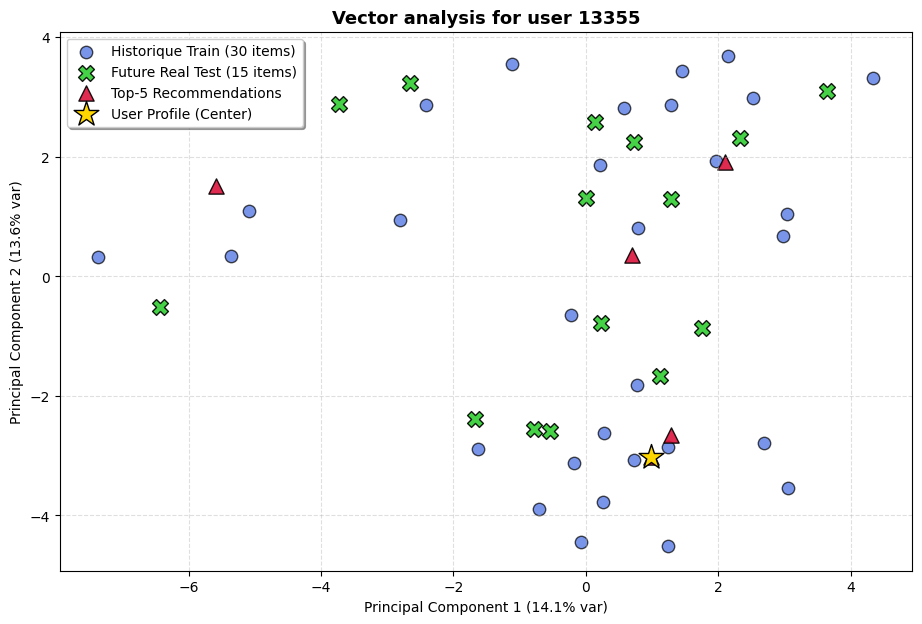

BPR recommendations for user 13355
🚀 Top-5 Recommandations BPR for user 13355 :
[48403, 31836, 299871, 288320, 233595]
Real reading:
[233688, 111043, 245161, 270607, 293513, 235870, 58565, 64409, 214631, 336221, 234267, 277491, 160142, 20691, 96210]
Matching items:
[]


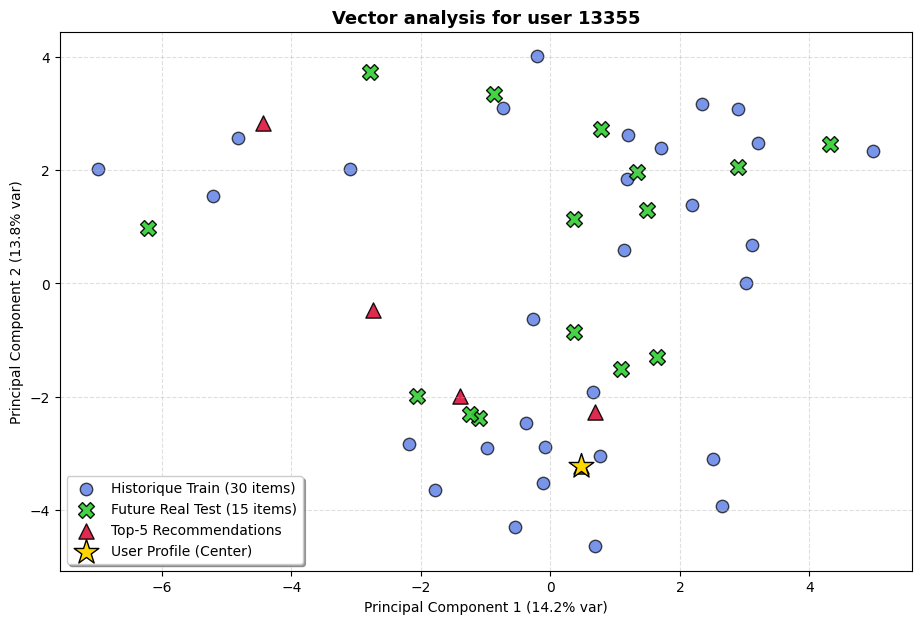

Item-Item recommendations for user 13355
🚀 Top-5 Recommandations Item-Item for user 13355 :
[272143, 199198, 272660, 160974, 338340]
Real reading:
[233688, 111043, 245161, 270607, 293513, 235870, 58565, 64409, 214631, 336221, 234267, 277491, 160142, 20691, 96210]
Matching items:
[]


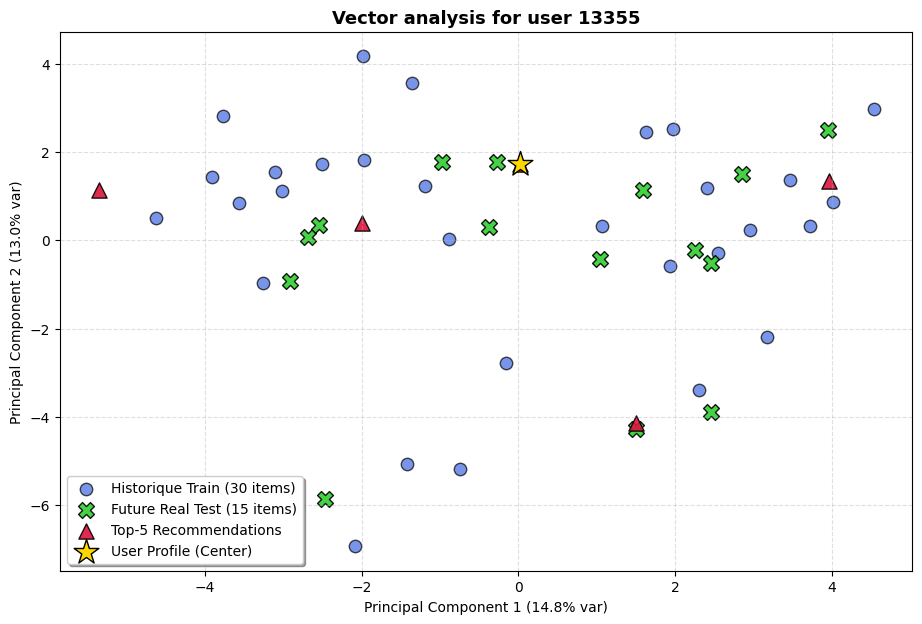

LMF recommendations for user 13355
🚀 Top-5 Recommandations LMF for user 13355 :
[149619, 286209, 160453, 292552, 338340]
Real reading:
[233688, 111043, 245161, 270607, 293513, 235870, 58565, 64409, 214631, 336221, 234267, 277491, 160142, 20691, 96210]
Matching items:
[]


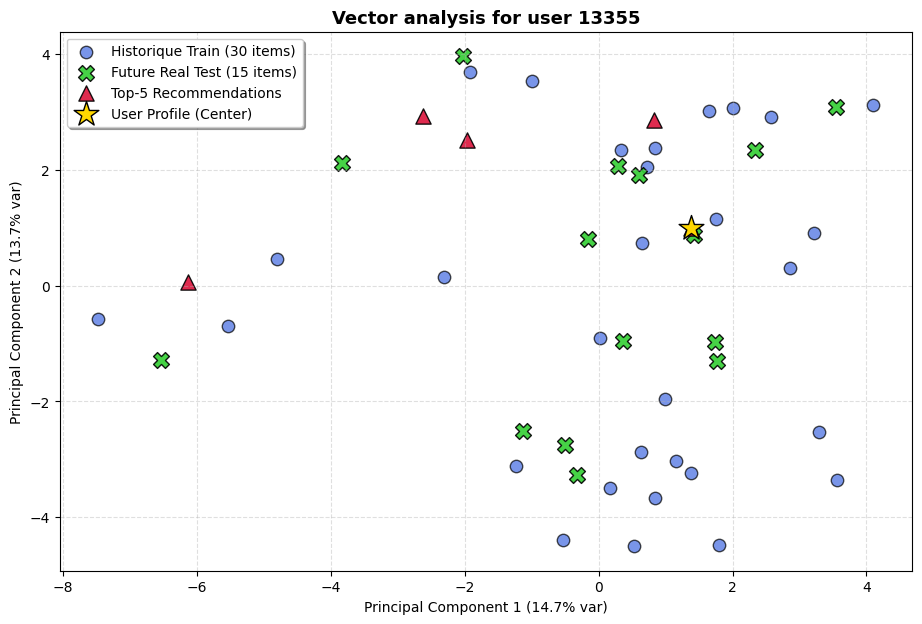

ALS recommendations for user 55206
🚀 Top-5 Recommandations ALS for user 55206 :
[225463, 168623, 337082, 95977, 271551]
Real reading:
[235854, 337192, 242596, 64409, 289003, 277107, 283009, 336254, 331116, 218028, 31068, 29953, 129520, 336221, 341963, 96532, 293218, 235870, 234698, 95716, 288435, 128260]
Matching items:
[]


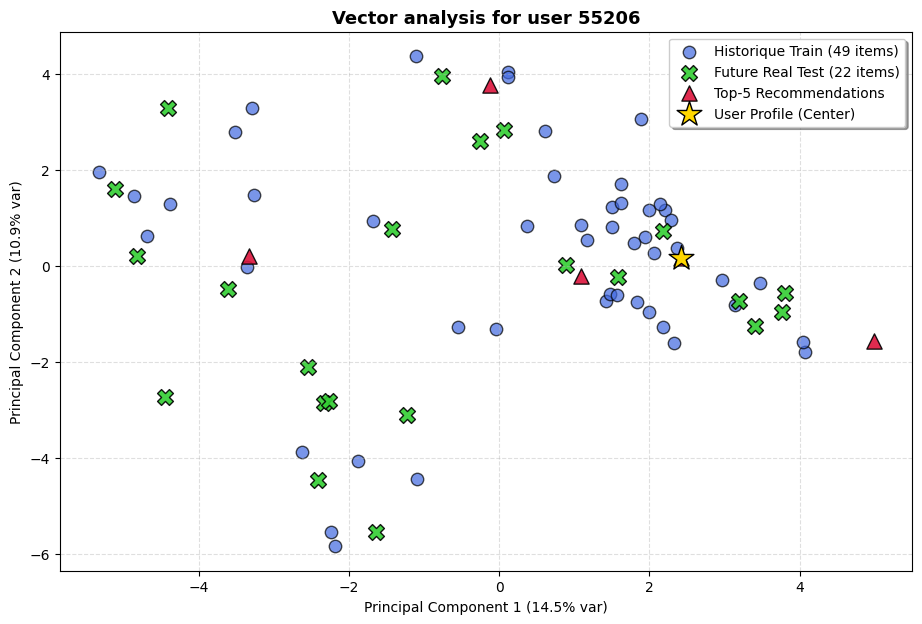

BPR recommendations for user 55206
🚀 Top-5 Recommandations BPR for user 55206 :
[277068, 95977, 198817, 141004, 288320]
Real reading:
[235854, 337192, 242596, 64409, 289003, 277107, 283009, 336254, 331116, 218028, 31068, 29953, 129520, 336221, 341963, 96532, 293218, 235870, 234698, 95716, 288435, 128260]
Matching items:
[]


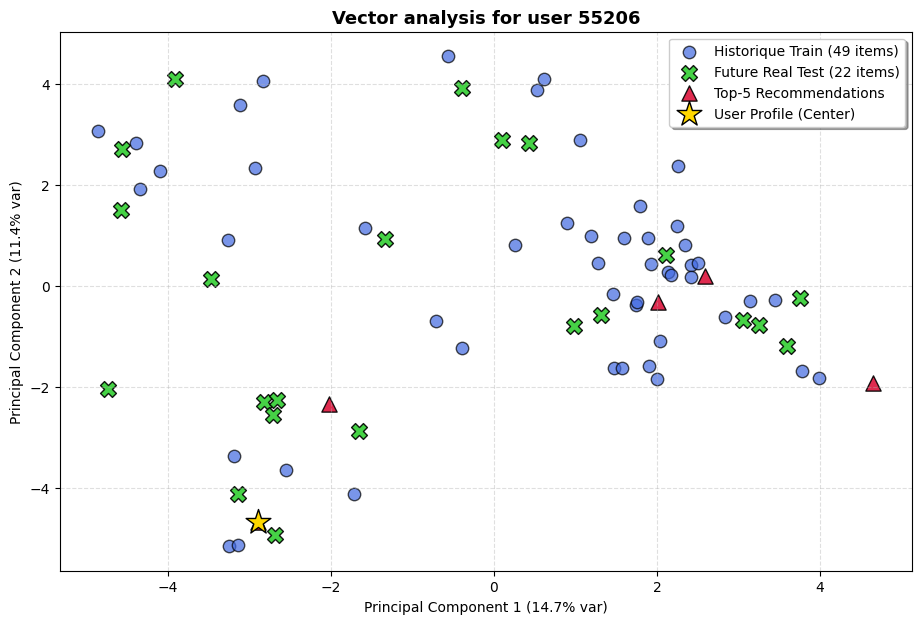

Item-Item recommendations for user 55206
🚀 Top-5 Recommandations Item-Item for user 55206 :
[272143, 199198, 123909, 160974, 198659]
Real reading:
[235854, 337192, 242596, 64409, 289003, 277107, 283009, 336254, 331116, 218028, 31068, 29953, 129520, 336221, 341963, 96532, 293218, 235870, 234698, 95716, 288435, 128260]
Matching items:
[]


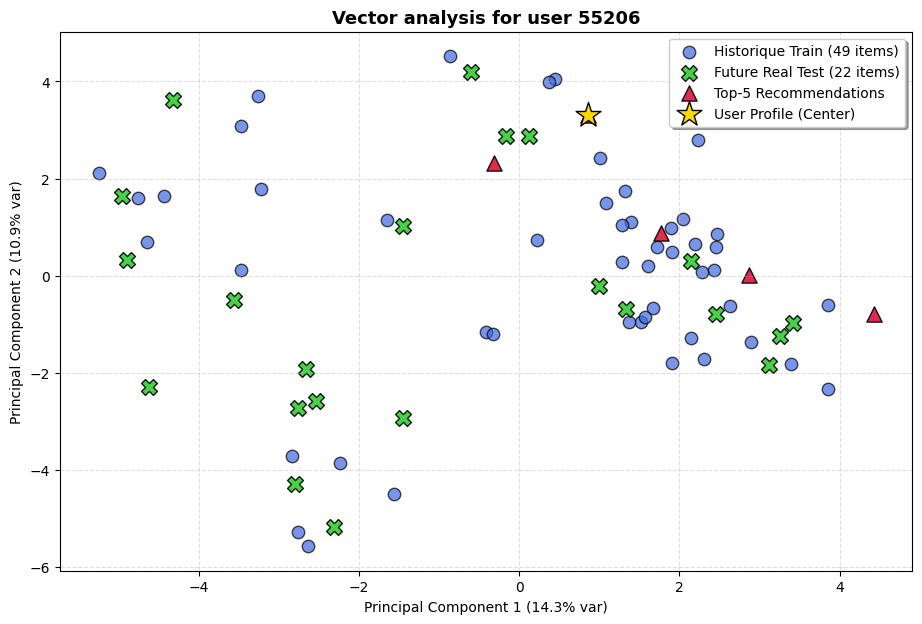

LMF recommendations for user 55206
🚀 Top-5 Recommandations LMF for user 55206 :
[235028, 284410, 288778, 198659, 288977]
Real reading:
[235854, 337192, 242596, 64409, 289003, 277107, 283009, 336254, 331116, 218028, 31068, 29953, 129520, 336221, 341963, 96532, 293218, 235870, 234698, 95716, 288435, 128260]
Matching items:
[]


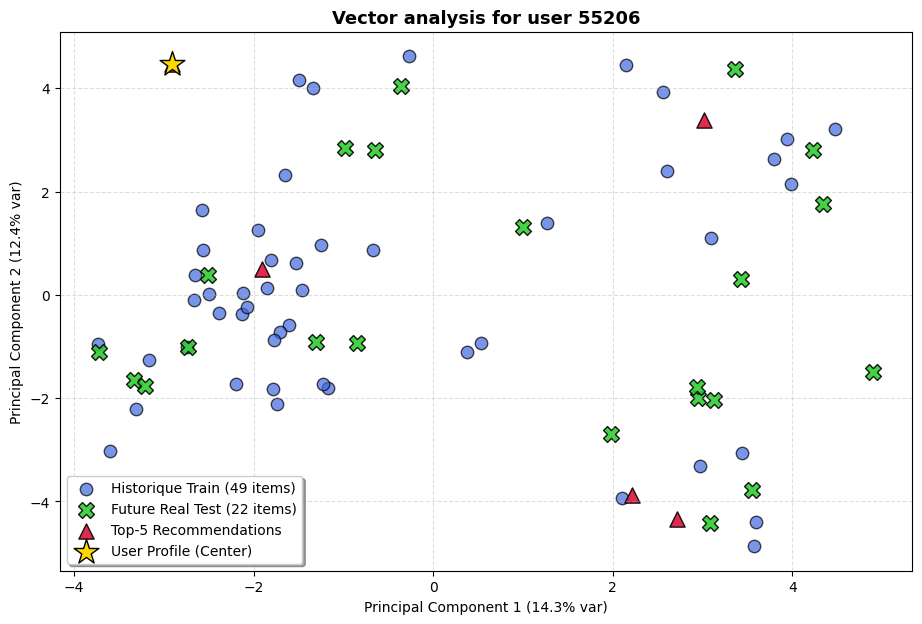

In [29]:
# Create a list of articles in the recent window
max_date = pd.to_datetime(train_df["click_timestamp"]).max()
limit_date = max_date - pd.Timedelta(days=DAYS_WINDOW)
recent_articles_idx = train_df[train_df["click_timestamp"] >= limit_date]["article_id"].dropna().astype(int).unique()
recent_articles_idx_set = set(recent_articles_idx)

allowed_items_idxs = [item_to_idx[aid] for aid in recent_articles_idx_set if aid in item_to_idx]

for demo_user in demo_users:
    demo_user_idx = user_to_idx[demo_user]

    real_readings = test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()

    # Get ALS recommendations
    print(f"ALS recommendations for user {demo_user}")
    # implicit returns matrixes indexes, that we need to revert to articles id
    ids_indices, _ = model_als.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True,
        items=allowed_items_idxs
    )
    recs_als = [idx_to_item[idx] for idx in ids_indices if idx in idx_to_item]


    print(f"🚀 Top-5 Recommandations ALS for user {demo_user} :")
    print(recs_als)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_als if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    original_candidates = CB_model.candidate_ids
    CB_model.candidate_ids = np.array(recs_als)

    # plot CB to get the user profile
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=list(recs_als), # Using ALS recommendations!
        data_loader=data_loader
    )
    CB_model.candidate_ids = original_candidates

    # Get BPR recommendations
    print(f"BPR recommendations for user {demo_user}")
    ids_indices, _ = model_bpr.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True,
        items=allowed_items_idxs
    )
    recs_bpr = [idx_to_item[idx] for idx in ids_indices if idx in idx_to_item]

    print(f"🚀 Top-5 Recommandations BPR for user {demo_user} :")
    print(recs_bpr)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_bpr if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    CB_model.candidate_ids = np.array(recs_bpr)
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=list(recs_bpr), # Using BPR recommendations!
        data_loader=data_loader
    )
    CB_model.candidate_ids = original_candidates

    print(f"Item-Item recommendations for user {demo_user}")
    ids_indices, _ = model_item_item.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True,
        items=allowed_items_idxs
    )
    recs_ii = [idx_to_item[idx] for idx in ids_indices if idx in idx_to_item][:5]

    print(f"🚀 Top-5 Recommandations Item-Item for user {demo_user} :")
    print(recs_ii)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_ii if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    CB_model.candidate_ids = original_candidates
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=list(recs_ii), # Using Item-Item recommendations!
        data_loader=data_loader
    )
    CB_model.candidate_ids = original_candidates

    # Get LMF recommendations
    print(f"LMF recommendations for user {demo_user}")
    ids_indices, _ = model_lmf.recommend(
        userid=demo_user_idx,
        user_items=user_item_matrix[demo_user_idx],
        N=5,
        filter_already_liked_items=True,
        items=allowed_items_idxs
    )
    recs_lmf = [idx_to_item[idx] for idx in ids_indices if idx in idx_to_item]

    print(f"🚀 Top-5 Recommandations LMF for user {demo_user} :")
    print(recs_lmf)
    print("Real reading:")
    print(test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist())
    print("Matching items:")
    print([item for item in recs_lmf if item in test_df.loc[test_df[USER_COL] == demo_user, ITEM_COL].dropna().astype(int).tolist()])

    # plot CB to get the user profile
    CB_model.candidate_ids = np.array(recs_lmf)
    plot_user_recommendations_2d(
        user_id=demo_user,
        recommender=CB_model, # Keep CB to have the user profile
        df_train=train_df,
        df_test=test_df,
        recommendations=list(recs_lmf), # Using LMF recommendations!
        data_loader=data_loader
    )
    CB_model.candidate_ids = original_candidates

Conclusion : 
The CF is not performing so well. This is justified by the fact that most articles in the test set are not known of the train set. Only 23% of articles from the test set are known in the train set.
In reality, 77% of articles read everyday are new. CF does not look at these articles and that is the reason why an hybrid approach can be interesting.

### 3.3 Two-Stage Recommendation (Hybrid)

Using content and collaborative approaches.
CB perform best on cold start as it can recommend new articles via embeddings. CF can't do that. Cf is not based on semantic but on behaviour on existing (old) articles.
CB is better for semantic but is missing collective engagement. CF understand behaviours but misses new articles. An hybrid approach is combining both :
1. Candidate Generation/Retrieval: Using CB to get the hundred most accurate articles for a user.
2. Ranking: Sort these hundred candidates using CF ALS score.

In [107]:
from typing import Dict, List

class HybridRecommender:
    """
    Hybrid recommender in two stages:
    Stage 1 : Selection of N candidates via Content-Based (Semantic).
    Stage 2 : Re-ranking of candidates via Collaborative Filtering ALS (Behavioral).
    """
    def __init__(self, cb_model: CBRecommender, cf_model, item_to_idx: dict, idx_to_item: dict, user_to_idx: dict, user_item_matrix: dict, days_window: int = 7, train_df: pd.DataFrame = None, test_df: pd.DataFrame = None):
        self.cb_model = cb_model
        self.cf_model = cf_model
        self.item_to_idx = item_to_idx
        self.idx_to_item = idx_to_item
        self.user_to_idx = user_to_idx
        self.user_item_matrix = user_item_matrix
        self.days_window = days_window
        self.train_df = train_df
        self.test_df = test_df

    def recommend_user(self, user_id: int, top_n: int = 5, candidate_pool_size: int = 100, alpha: float = 0.3, train_df: pd.DataFrame = None, test_df: pd.DataFrame = None) -> List[int]:
        """Generate hybrid recommendations for a unique user."""

        # Stage 1 : CB candidates
        cb_recs = self.cb_model.recommend_batch([user_id], n=candidate_pool_size, days_window=self.days_window, train_df=train_df, test_df=test_df)
        candidates = cb_recs.get(user_id, [])

        if not candidates:
            return []

        # If the CF model does not know the user, return the top of the CB basket
        if user_id not in self.user_to_idx:
            return candidates[:top_n]

        user_idx = self.user_to_idx[user_id]

        # Stage 2 : CF re-ranking
        n_cf_items = self.cf_model.item_factors.shape[0]
        candidate_idxs = [self.item_to_idx[aid] for aid in candidates
                            if aid in self.item_to_idx
                            and self.item_to_idx[aid] < n_cf_items
                            ]

        if not candidate_idxs:
            return candidates[:top_n]

        # Score CB : normalized reversed ranking (position 0 =  score 1.0)
        n = len(candidates)
        cb_rank_score = { aid: (n - i) / n for i, aid in enumerate(candidates)}

        # CF score
        ids, scores = self.cf_model.recommend(
            userid=user_idx,
            user_items=self.user_item_matrix[user_idx],
            N=len(candidate_idxs),
            items=candidate_idxs,
            filter_already_liked_items=True
        )
        cf_scores_dict = {self.idx_to_item[item_idx]: score for item_idx, score in zip(ids, scores)}

        # Normalize CF between 0 and 1
        if cf_scores_dict:
            cf_min = min(cf_scores_dict.values())
            cf_max = max(cf_scores_dict.values())
            cf_range = cf_max - cf_min if cf_max != cf_min else 1.0
            cf_norm = {k: (v - cf_min) / cf_range for k, v in cf_scores_dict.items()}
        else:
            cf_norm = {k: 0.0 for k in candidates}

        # Combine scores
        hybrid_candidates = sorted(
            candidates,
            key=lambda aid: alpha * cf_norm.get(aid, 0.0) + (1 - alpha) * cb_rank_score[aid],
            reverse=True
        )

        return hybrid_candidates[:top_n]

    def evaluate(self, test_df: pd.DataFrame, topk: int = 5, candidate_pool_size: int = 100, threshold: float = 0.7, alpha: float = 0.3) -> pd.DataFrame:
        """Evaluate the Hit Rate of the hybrid model on the test set."""

        recall_ks = [5, 10, 20]
        max_k = max(topk, max(recall_ks))

        test_grouped = test_df.groupby(self.cb_model.user_col)[self.cb_model.item_col].apply(set).to_dict()
        valid_users = [uid for uid in test_grouped.keys() if uid in self.cb_model.user_profiles]

        hits = []
        soft_hits = []
        recall_scores = {k: [] for k in recall_ks}

        for uid in valid_users:
            true_items = test_grouped[uid]
            n_relevant = len(true_items)

            predicted_items = self.recommend_user(uid, top_n=max_k, candidate_pool_size=candidate_pool_size, alpha=alpha, train_df=self.train_df, test_df=self.test_df)

            if not predicted_items:
                soft_hits.append(0.0)
                hits.append(0.0)
                continue

            predicted_topk = predicted_items[:topk]
            has_hit = any(item in true_items for item in predicted_topk)
            hits.append(1.0 if has_hit else 0.0)

            if has_hit:
                soft_hits.append(1.0)
            else:
                user_profile = self.cb_model.user_profiles[uid]
                u_norm = np.linalg.norm(user_profile)

                if u_norm == 0:
                    soft_hits.append(0.0)
                    continue

                user_soft_scores = []
                for item in predicted_items:
                    item_idx = self.cb_model.article_to_idx.get(item)
                    if item_idx is None:
                        user_soft_scores.append(0.0)
                        continue

                    item_emb = self.cb_model.candidate_embeddings[item_idx]
                    item_norm = self.cb_model.candidate_norms[item_idx]

                    cosine_sim = (item_emb @ user_profile) / (item_norm * u_norm)
                    user_soft_scores.append(cosine_sim)

                if user_soft_scores and max(user_soft_scores) >= threshold:
                    soft_hits.append(0.5)
                else:
                    soft_hits.append(0.0)

            # Recall@K
            for k in recall_ks:
                predicted_k = predicted_items[:k]
                n_hits_k = sum(1 for item in predicted_k if item in true_items)
                recall_scores[k].append(
                    min(n_hits_k / n_relevant, 1.0) if n_relevant > 0 else 0.0
                )

        results = {
            "acc@5": float(np.mean(hits).round(4)),
            "soft@5": float(np.mean(soft_hits).round(4)),
        }
        for k in recall_ks:
            results[f"recall@{k}"] = float(np.mean(recall_scores[k]).round(4))

        return pd.DataFrame([results])


In [ ]:

def plot_hybrid_recommendations_2d(user_id: int, hybrid_model, df_train: pd.DataFrame, df_test: pd.DataFrame, data_loader, top_n=10, pool_size=100):
    """
    Visualise the two stages of the hybrid model:
    The global pool of candidates (CB) and the final selection reordered (CF).
    """
    # 1. Retrieval of histories and futures
    train_aids = df_train.loc[df_train[hybrid_model.cb_model.user_col] == user_id, hybrid_model.cb_model.item_col].dropna().astype(int).tolist()
    test_aids = df_test.loc[df_test[hybrid_model.cb_model.user_col] == user_id, hybrid_model.cb_model.item_col].dropna().astype(int).tolist()

    # 2. Retrieval of the two stages of the hybrid
    # Step 1: The large pool of Content-Based
    cb_recs = hybrid_model.cb_model.recommend_batch([user_id], n=pool_size, days_window=hybrid_model.days_window)
    candidate_pool = cb_recs.get(user_id, [])

    # Step 2: The final selection reordered by the CF
    final_recs = hybrid_model.recommend_user(user_id, top_n=top_n, candidate_pool_size=pool_size)

    if not train_aids or not candidate_pool:
        print(f"⚠️ Insufficient data for user {user_id}")
        return

    # 3. Extraction of embeddings
    user_profile = hybrid_model.cb_model.user_profiles.get(user_id).reshape(1, -1)
    train_embs = data_loader.get_embeddings_by_ids(train_aids)
    test_embs = data_loader.get_embeddings_by_ids(test_aids) if test_aids else np.array([])
    pool_embs = data_loader.get_embeddings_by_ids(candidate_pool)

    # To highlight the final choices, we search for their index in the pool
    final_set = set(final_recs)

    # 4. Alignment PCA
    matrices = [train_embs, pool_embs]
    if test_embs.size > 0:
        matrices.append(test_embs)
    matrices.append(user_profile)

    all_embs = np.vstack(matrices)
    pca = PCA(n_components=2, random_state=42)
    all_embs_2d = pca.fit_transform(all_embs)

    # Splitting
    idx = 0
    train_2d = all_embs_2d[idx : idx + len(train_aids)]; idx += len(train_aids)
    pool_2d = all_embs_2d[idx : idx + len(candidate_pool)]; idx += len(candidate_pool)
    if test_embs.size > 0:
        test_2d = all_embs_2d[idx : idx + len(test_aids)]; idx += len(test_aids)
    profile_2d = all_embs_2d[idx]

    # Separation in the pool: rejected candidates VS candidates selected by the CF
    final_indices = [i for i, aid in enumerate(candidate_pool) if aid in final_set]
    rejected_indices = [i for i, aid in enumerate(candidate_pool) if aid not in final_set]

    # 5. Plotting the graph
    plt.figure(figsize=(12, 8))

    # Train and Test
    plt.scatter(train_2d[:, 0], train_2d[:, 1], color='royalblue', alpha=0.6, edgecolors='k', s=80, label='History (Train)')
    if test_embs.size > 0:
        plt.scatter(test_2d[:, 0], test_2d[:, 1], color='limegreen', alpha=0.9, edgecolors='k', s=150, marker='X', label='Futur Réel (Test)')

    # Initial semantic profile
    plt.scatter(profile_2d[0], profile_2d[1], color='gold', edgecolor='black', s=300, marker='*', label='Initial Profile (CB Mean)', zorder=5)

    # Step 1: The global pool of candidates found by the CB (in orange/diamond)
    if rejected_indices:
        plt.scatter(pool_2d[rejected_indices, 0], pool_2d[rejected_indices, 1], color='darkorange', alpha=0.3, marker='d', s=60, label='CB Candidates (Step 1 - Eliminated)')

    # Step 2: The winners selected by the CF (in red/triangle)
    if final_indices:
        plt.scatter(pool_2d[final_indices, 0], pool_2d[final_indices, 1], color='crimson', alpha=0.9, marker='^', edgecolors='k', s=120, label=f'Top-{top_n} Hybrid Selection (Step 2)')

    plt.title(f"Analyse Géométrique du Moteur Hybride - User {user_id}", fontsize=14, fontweight='bold')
    plt.xlabel("Composante Principale 1")
    plt.ylabel("Composante Principale 2")
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

In [ ]:
hybrid_model = HybridRecommender(
    cb_model=base,
    cf_model=model_als,
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item,
    user_to_idx=user_to_idx,
    user_item_matrix=scaled_matrix,
    days_window=DAYS_WINDOW,
    train_df=train_df,
    test_df=test_df
)

# 2. Global evaluation
print("Global evaluation of the hybrid model...")
results_hybrid = hybrid_model.evaluate(test_df, topk=5, candidate_pool_size=100, alpha=0.3)

results_hybrid['strategy'] = 'hybrid'

results_df = pd.concat([results_df, results_hybrid])
display(results_df)


In [111]:
sample_users = test_df["user_id"].drop_duplicates().sample(2000, random_state=42)
test_df_sample = test_df[test_df["user_id"].isin(sample_users)]

results = hybrid_model.evaluate(test_df_sample, topk=5, candidate_pool_size=100, alpha=0.0)

display(results)

,acc@5,soft@5,recall@5,recall@10,recall@20
0,0.0195,0.5072,0.002,0.0039,0.0077


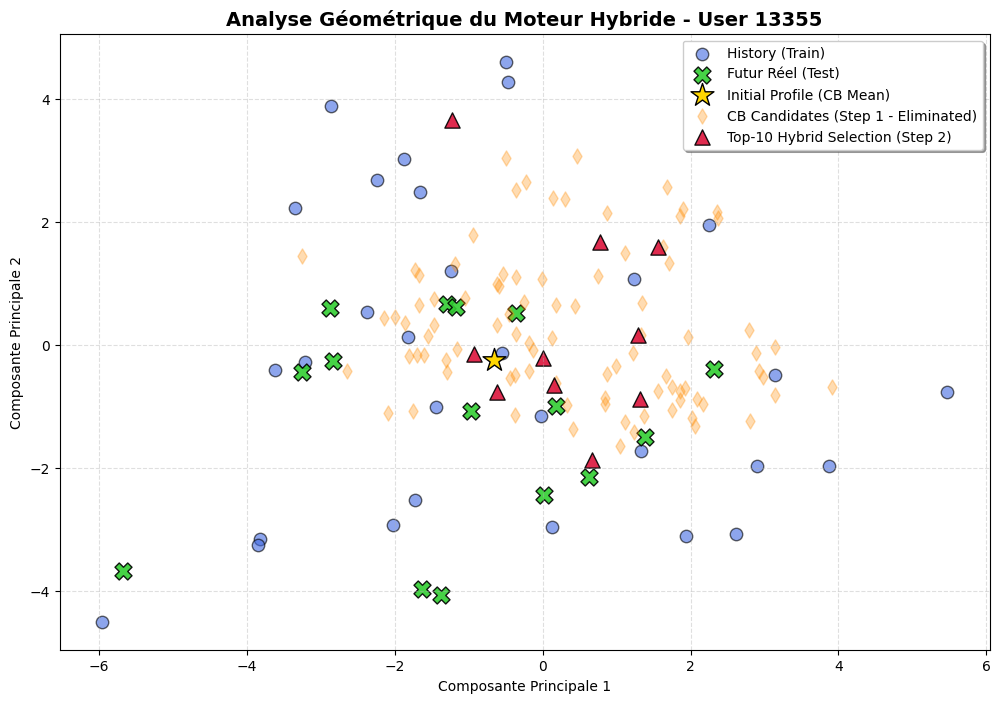

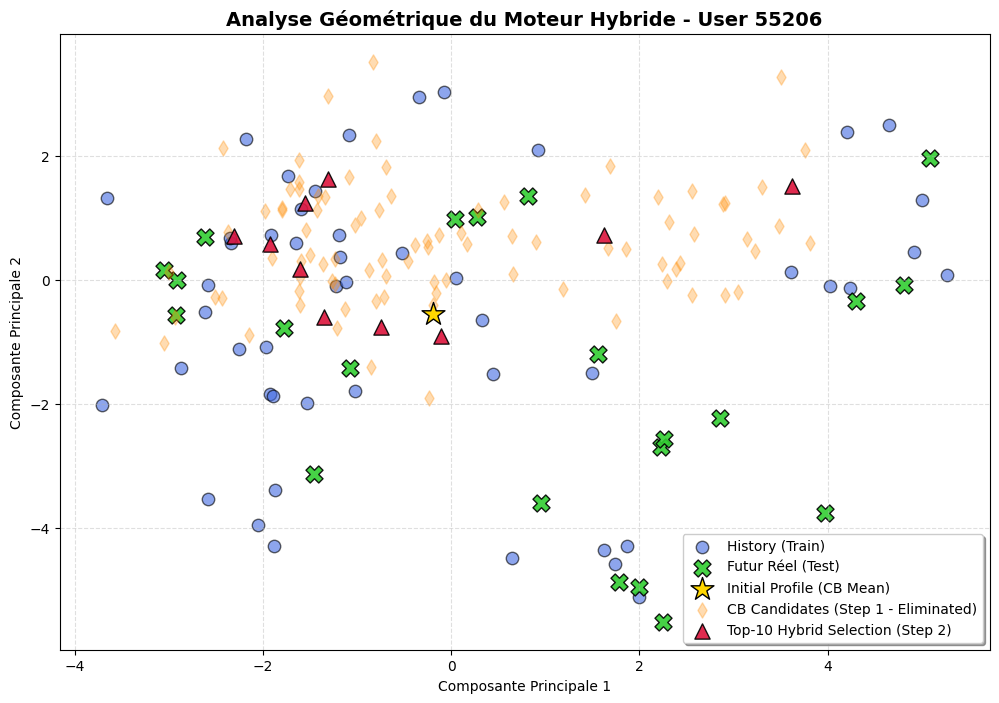

In [45]:
for demo_user in demo_users:
    plot_hybrid_recommendations_2d(
        user_id=demo_user,
        hybrid_model=hybrid_model,
        df_train=train_df,
        df_test=test_df,
        data_loader=data_loader,
        top_n=10,
        pool_size=100
    )

### Fine tuning the best strategy

We are going tu use weights on clicks. We will start by neutralizing popularity (article with the most of clicks) noice and bias using a grid search.

#### CF strategy

In [52]:
from implicit.als import AlternatingLeastSquares

iterations = 20

def grid_search_als(train_df, user_item_matrix, item_to_idx, idx_to_item, windows_to_test, factors_values, regularization_values, iterations):
    results_grid = []

    print("🚀 Launching grid search...\n")

    # 1. Iterate over the temporal window
    for window in windows_to_test:
        # 2. Iterate over the ALS parameters
        for factors in factors_values:
            for reg in regularization_values:
                print(f"Testing: Window={window}d | Factors={factors} | Reg={reg}")

                model = AlternatingLeastSquares(factors=factors, regularization=reg, iterations=iterations, random_state=42)
                # Entraînement sur la matrice globale (pas de filtre ici)
                model.fit(user_item_matrix.astype(np.float32), show_progress=False)

                # Évaluation sous CONTRAINTE de la fenêtre en cours
                # On passe explicitement allowed_items_idxs à la fonction d'évaluation
                acc5 = evaluate_implicit_model(
                    model, user_item_matrix.astype(np.float32), test_df,
                    item_to_idx, idx_to_item, topk=5, days_window=window, timestamp_col="click_timestamp", item_col=ITEM_COL
                )
                acc10 = evaluate_implicit_model(
                    model, user_item_matrix.astype(np.float32), test_df,
                    item_to_idx, idx_to_item, topk=10, days_window=window, timestamp_col="click_timestamp", item_col=ITEM_COL
                )

                results_grid.append({
                    "Window (Days)": window,
                    "Factors": factors,
                    "Regularization": reg,
                    "Accuracy@5": acc5,
                    "Accuracy@10": acc10
                })
    return pd.DataFrame(results_grid).sort_values(by="Accuracy@5", ascending=False).reset_index(drop=True)

#### Best Model based on the Hit@5

In [53]:
# Grid search definition
windows_to_test = [3, 7, 10]
factors_values = [64, 128]
regularization_values = [0.1, 1.0]

df_global_tuning = grid_search_als(train_df, user_item_matrix, item_to_idx, idx_to_item, windows_to_test, factors_values, regularization_values, iterations)
display(df_global_tuning)

🚀 Launching grid search...

Testing: Window=3d | Factors=64 | Reg=0.1
Testing: Window=3d | Factors=64 | Reg=1.0
Testing: Window=3d | Factors=128 | Reg=0.1
Testing: Window=3d | Factors=128 | Reg=1.0
Testing: Window=7d | Factors=64 | Reg=0.1
Testing: Window=7d | Factors=64 | Reg=1.0
Testing: Window=7d | Factors=128 | Reg=0.1
Testing: Window=7d | Factors=128 | Reg=1.0
Testing: Window=10d | Factors=64 | Reg=0.1
Testing: Window=10d | Factors=64 | Reg=1.0
Testing: Window=10d | Factors=128 | Reg=0.1
Testing: Window=10d | Factors=128 | Reg=1.0


,Window (Days),Factors,Regularization,Accuracy@5,Accuracy@10
0,3,64,1.0,0.0100,0.0187
1,7,64,1.0,0.0100,0.0187
2,10,64,1.0,0.0100,0.0187
3,3,64,0.1,0.0097,0.0178
4,7,64,0.1,0.0097,0.0178
5,10,64,0.1,0.0097,0.0178
6,3,128,1.0,0.0044,0.0075
7,7,128,1.0,0.0044,0.0075
8,10,128,1.0,0.0044,0.0075
9,3,128,0.1,0.0038,0.0072


Observations :

- temporal window : For a same couple of hyperparameters (ex Factors=64, Reg=1.0), the score is the same no matter the window. As we ask a top N = 15 (3 * topk) articles, we get the top-15 no matter what. if top 5 have less than 3 days, they would stay on the top of the ranking no matter what

- Factors : The highest the factor, the lowest is the score. It shows the ALS overfitting on a sparse matrix. Giving more liberty to the model, ALS is taking into account the noise and outliers clics in the train set instead of focusing of the main tendancy and then, can't generalize on the test set.

Actions :

We wil try a gridsearch on the 7 days temporal window and lower factors. We'll also work on stronger regularization as it is preferred for ALS strategy on unbalanced dataset.

In [54]:
windows_to_test = [7]
factors_values = [16, 32, 64]
regularization_values = [1.0, 5.0, 10.0]

df_global_tuning = grid_search_als(train_df, user_item_matrix, item_to_idx, idx_to_item, windows_to_test, factors_values, regularization_values, iterations)
display(df_global_tuning)


🚀 Launching grid search...

Testing: Window=7d | Factors=16 | Reg=1.0
Testing: Window=7d | Factors=16 | Reg=5.0
Testing: Window=7d | Factors=16 | Reg=10.0
Testing: Window=7d | Factors=32 | Reg=1.0
Testing: Window=7d | Factors=32 | Reg=5.0
Testing: Window=7d | Factors=32 | Reg=10.0
Testing: Window=7d | Factors=64 | Reg=1.0
Testing: Window=7d | Factors=64 | Reg=5.0
Testing: Window=7d | Factors=64 | Reg=10.0


,Window (Days),Factors,Regularization,Accuracy@5,Accuracy@10
0,7,16,5.0,0.0146,0.0253
1,7,16,1.0,0.0145,0.0252
2,7,16,10.0,0.0145,0.0252
3,7,64,5.0,0.0101,0.0190
4,7,64,10.0,0.0101,0.0188
5,7,32,5.0,0.0100,0.0166
6,7,32,10.0,0.0100,0.0168
7,7,64,1.0,0.0100,0.0187
8,7,32,1.0,0.0099,0.0164


#### Best model for soft hit @5
The CB might have the best soft hit score, however, this recommendation system does not capture the other factors that engage the user to click on an article. We will try to upgrade the hybrid recommender score as it sounds the most balanced option to keep the semantic theme of the user while engaging them whith the moment hot topics.

In [ ]:
CB_model = CBRecommender(data_loader=data_loader)
CB_model.fit(train_df, strategy="category")

pool_sizes = [50, 100, 200, 300]
factors_values = [64, 128]
regularization = 5.0 # The best regularization found in the previous grid search

hybrid_tuning_results = []

for pool_size in pool_sizes:
    for factors in factors_values:
        print(f"🔬 Test : Pool Size CB = {pool_size} | ALS Factors = {factors}")

        # 1. Instanciation of the ALS with the test parameters
        als_model = AlternatingLeastSquares(factors=factors, regularization=regularization, iterations=20, random_state=42)
        als_model.fit(user_item_matrix.astype(np.float32), show_progress=False)

        # 2. Update of the hybrid model
        hybrid_model = HybridRecommender(
            cb_model=CB_model,
            cf_model=als_model,
            item_to_idx=item_to_idx,
            idx_to_item=idx_to_item,
            days_window=7 # Fixed window for the test
        )

        # 3. Double evaluation (Classic & Soft Hit)
        acc5, soft5 = hybrid_model.evaluate(
            cb_model=CB_model,
            test_df=test_df,
            topk=5,
            candidate_pool_size=pool_size,
            threshold=0.7,
        )

        hybrid_tuning_results.append({
            "Pool Size CB": pool_size,
            "ALS Factors": factors,
            "Accuracy@5": acc5,
            "Soft Hit@5": soft5
        })

# Restructuration in DataFrame
df_hybrid_tuning = pd.DataFrame(hybrid_tuning_results)
display(df_hybrid_tuning.sort_values(by="Accuracy@5", ascending=False))

🔬 Test : Pool Size CB = 50 | ALS Factors = 64
🔬 Test : Pool Size CB = 50 | ALS Factors = 128
🔬 Test : Pool Size CB = 100 | ALS Factors = 64
🔬 Test : Pool Size CB = 100 | ALS Factors = 128
🔬 Test : Pool Size CB = 200 | ALS Factors = 64
🔬 Test : Pool Size CB = 200 | ALS Factors = 128
🔬 Test : Pool Size CB = 300 | ALS Factors = 64
🔬 Test : Pool Size CB = 300 | ALS Factors = 128


,Pool Size CB,ALS Factors,Accuracy@5,Soft Hit@5
4,200,64,0.0058,0.3084
6,300,64,0.0057,0.2619
2,100,64,0.0050,0.3772
5,200,128,0.0050,0.3066
0,50,64,0.0047,0.4277
1,50,128,0.0047,0.4277
3,100,128,0.0047,0.3759
7,300,128,0.0044,0.2613


In [112]:
from itertools import product
from tqdm import tqdm

alphas = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
pool_sizes = [50, 100, 200]

gs_results = []

for alpha, pool_size in tqdm(list(product(alphas, pool_sizes))):
    results = hybrid_model.evaluate(
        test_df_sample, topk=5,
        candidate_pool_size=pool_size,
        alpha=alpha
    )
    results['alpha'] = alpha
    results['pool_size'] = pool_size
    gs_results.append(results)

gs_df = pd.concat(gs_results).sort_values("acc@5", ascending=False)
display(gs_df)

100%|██████████| 21/21 [31:20<00:00, 89.57s/it]


,acc@5,soft@5,recall@5,recall@10,recall@20,alpha,pool_size
0,0.0195,0.5072,0.0020,0.0039,0.0077,0.0,50
0,0.0195,0.5072,0.0020,0.0039,0.0077,0.0,100
0,0.0195,0.5072,0.0020,0.0039,0.0077,0.0,200
0,0.0180,0.5065,0.0018,0.0039,0.0075,0.1,50
0,0.0165,0.5058,0.0015,0.0035,0.0069,0.1,100
0,0.0155,0.5052,0.0014,0.0035,0.0069,0.2,50
0,0.0130,0.5038,0.0010,0.0031,0.0067,0.3,50
0,0.0120,0.5032,0.0010,0.0029,0.0064,0.1,200
0,0.0110,0.5028,0.0009,0.0028,0.0064,0.2,100
0,0.0075,0.5002,0.0007,0.0011,0.0032,0.5,100


As a conclusion of this test, the greater is alpha, the lower is the accuracy weight as we are losing the CB scores. To keep the notion of trendy articles, we introduce the notion of popularity in th CBRecommender. Let's test this.

In [ ]:
cb_model = CBRecommender(data_loader=data_loader)
cb_model.fit(train_df, strategy="category")

betas = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
betas2 = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
betas3 = [0.75, 0.78, 0.80, 0.82, 0.85]


# pop_results = []
# pop_results2 = []
pop_results3 = []
for beta in betas3:
    results = cb_model.evaluate(
        test_df, topk=5,
        train_df=train_df,
        days_window=DAYS_WINDOW,
        beta=beta
    )
    results['beta'] = beta
    pop_results3.append(results)

pop_df3 = pd.concat(pop_results3).sort_values("acc@5", ascending=False)
display(pop_df)
display(pop_df3)


1/3. Loading and indexing article catalogue...
2/3. Mapping user histories...
3/3. Calculating user profiles according to strategy: 'category'...
4/4. Loading popularity scores...
Model ready for predictions.


,acc@5,soft@5,recall@5,recall@10,recall@20,beta
0,0.4343,0.6181,0.0554,0.1005,0.1620,0.50
0,0.3105,0.4218,0.0358,0.0554,0.0779,0.30
0,0.1527,0.2876,0.0162,0.0236,0.0338,0.20
0,0.0545,0.4185,0.0052,0.0087,0.0148,0.10
0,0.0339,0.4939,0.0031,0.0058,0.0106,0.05
0,0.0247,0.5093,0.0022,0.0044,0.0084,0.00


NameError: name 'pop_df2' is not defined

In [ ]:
display(pop_results2)

[    acc@5  soft@5  recall@5  recall@10  recall@20  beta
 0  0.4343  0.6181    0.0554     0.1005      0.162   0.5,
     acc@5  soft@5  recall@5  recall@10  recall@20  beta
 0  0.4636  0.6958    0.0609     0.1071     0.1679   0.6,
     acc@5  soft@5  recall@5  recall@10  recall@20  beta
 0  0.4766  0.7351    0.0641     0.1083     0.1718   0.7,
     acc@5  soft@5  recall@5  recall@10  recall@20  beta
 0  0.4818  0.7409    0.0653     0.1067     0.1727   0.8,
     acc@5  soft@5  recall@5  recall@10  recall@20  beta
 0  0.4812  0.7406    0.0652     0.1043     0.1717   0.9,
    acc@5  soft@5  recall@5  recall@10  recall@20  beta
 0    0.0     0.0       0.0        0.0        0.0   1.0]

In [11]:
display(pop_df3)

,acc@5,soft@5,recall@5,recall@10,recall@20,beta
0,0.4826,0.7413,0.0656,0.1055,0.1716,0.85
0,0.4818,0.7409,0.0653,0.1067,0.1727,0.80
0,0.4818,0.7409,0.0654,0.1062,0.1722,0.82
0,0.4812,0.7406,0.0652,0.1071,0.1729,0.78
0,0.4799,0.7397,0.0649,0.1076,0.1728,0.75


### PCA

In [14]:
from sklearn.decomposition import PCA
import copy

results_pca = []

for target, n_components in [(0.80, 27), (0.85, 33), (0.90, 40), (0.95, 52)]:

    # Model copy to avoid modifying the original
    cb_pca = copy.copy(cb_model)

    # Fit PCA on candidate embeddings
    pca = PCA(n_components=n_components, random_state=42)
    cb_pca.candidate_embeddings = pca.fit_transform(cb_model.candidate_embeddings).astype(np.float32)
    cb_pca.candidate_norms = np.linalg.norm(cb_pca.candidate_embeddings, axis=1)
    cb_pca.candidate_norms = np.where(cb_pca.candidate_norms == 0, 1e-12, cb_pca.candidate_norms)

    # Reduce user profiles with the same pca (transform, not fit_transform)
    user_ids_list = list(cb_model.user_profiles.keys())
    profiles_matrix = np.array([cb_model.user_profiles[uid] for uid in user_ids_list])
    reduced_profiles = pca.transform(profiles_matrix)
    cb_pca.user_profiles = {uid: reduced_profiles[i].astype(np.float32)
                            for i, uid in enumerate(user_ids_list)}

    # Evaluation
    results = cb_pca.evaluate(
        test_df, topk=5,
        train_df=train_df,
        days_window=DAYS_WINDOW,
        beta=0.8
    )
    results['variance'] = target
    results['n_components'] = n_components
    results['total_mb'] = [44.2, 54.0, 65.4, 85.1][[0.80, 0.85, 0.90, 0.95].index(target)]
    results_pca.append(results)

pca_df = pd.concat(results_pca)
# Add the reference line without PCA
ref = pd.DataFrame([{"acc@5": 0.4818, "variance": "no PCA",
                      "n_components": len(cb_model.candidate_embeddings[0]),
                      "total_mb": 424}])
display(pd.concat([ref, pca_df]))

,acc@5,variance,n_components,total_mb,soft@5,recall@5,recall@10,recall@20
0,0.4818,no PCA,250,424.0,NaN,NaN,NaN,NaN
0,0.4730,0.8,27,44.2,0.7336,0.0632,0.1076,0.1733
0,0.4744,0.85,33,54.0,0.7341,0.0635,0.1075,0.1734
0,0.4739,0.9,40,65.4,0.7332,0.0634,0.1074,0.1732
0,0.4739,0.95,52,85.1,0.7328,0.0635,0.1075,0.1729


Reducing the dimensionality of our matrices does not affect the results much.
PCA 85% seems to be the best option we reduce the size by 8 while losing only  1,5% of our results

### Export best model after PCA

In [15]:
# Apply the retained PCA on the final model
pca_final = PCA(n_components=33, random_state=42)

cb_model.candidate_embeddings = pca_final.fit_transform(
    cb_model.candidate_embeddings
).astype(np.float32)
cb_model.candidate_norms = np.linalg.norm(cb_model.candidate_embeddings, axis=1)
cb_model.candidate_norms = np.where(
    cb_model.candidate_norms == 0, 1e-12, cb_model.candidate_norms
)

# User profiles with the same pca
user_ids_list = list(cb_model.user_profiles.keys())
profiles_matrix = np.array([cb_model.user_profiles[uid] for uid in user_ids_list])
reduced_profiles = pca_final.transform(profiles_matrix)
cb_model.user_profiles = {
    uid: reduced_profiles[i].astype(np.float32)
    for i, uid in enumerate(user_ids_list)
}

# Save the pca_final for production inference
import pickle
with open("pca_final.pkl", "wb") as f:
    pickle.dump(pca_final, f)

print("PCA applied — model ready for export")

PCA applied — model ready for export


## Export artifacts to blob

In [19]:
import os
import json
from dotenv import load_dotenv
from datetime import datetime, timezone
from azure.storage.blob import BlobServiceClient

load_dotenv()
CONNECTION_STRING = os.environ.get("AZURE_STORAGE_CONNECTION_STRING")
CONTAINER = "recommenderv1"
BETA = 0.8

def upload_artifact(container_client, name, obj):
    data = pickle.dumps(obj, protocol=pickle.HIGHEST_PROTOCOL)
    container_client.get_blob_client(name).upload_blob(data, overwrite=True)
    print(f"  ✅ {name} ({len(data)/1024**2:.1f} MB)")

# Connexion
service_client = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container_client = service_client.get_container_client(CONTAINER)
try:
    container_client.create_container()
except:
    pass  # already exists

# Export
print("Uploading artifacts...")
upload_artifact(container_client, "candidate_ids.pkl",         cb_model.candidate_ids)
upload_artifact(container_client, "candidate_embeddings.pkl",  cb_model.candidate_embeddings)
upload_artifact(container_client, "candidate_norms.pkl",       cb_model.candidate_norms)
upload_artifact(container_client, "article_to_idx.pkl",        cb_model.article_to_idx)
upload_artifact(container_client, "user_profiles.pkl",         cb_model.user_profiles)
upload_artifact(container_client, "user_seen.pkl",             cb_model.user_seen)
upload_artifact(container_client, "popularity_scores.pkl",     cb_model.popularity_scores)
upload_artifact(container_client, "pca_final.pkl",             pca_final)

# Manifest
manifest = {
    "exported_at": datetime.now(timezone.utc).isoformat(),
    "n_articles":  int(len(cb_model.candidate_ids)),
    "n_users":     int(len(cb_model.user_profiles)),
    "beta":        BETA,
    "n_components_pca": 33,
}
container_client.get_blob_client("manifest.json").upload_blob(
    json.dumps(manifest, indent=2).encode(), overwrite=True
)
print("  ✅ manifest.json")
print(f"\n🎉 Export completed — {manifest['n_articles']:,} articles, {manifest['n_users']:,} users")

Uploading artifacts...
  ✅ candidate_ids.pkl (2.8 MB)
  ✅ candidate_embeddings.pkl (45.8 MB)
  ✅ candidate_norms.pkl (1.4 MB)
  ✅ article_to_idx.pkl (3.2 MB)
  ✅ user_profiles.pkl (10.0 MB)
  ✅ user_seen.pkl (4.5 MB)
  ✅ popularity_scores.pkl (1.0 MB)
  ✅ pca_final.pkl (0.0 MB)
  ✅ manifest.json

🎉 Export completed — 364,047 articles, 64,734 users
